In [1]:
import numpy as np


In [2]:
import scanpy as sc
import glasbey

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import scanpy as sc
#import squidpy as sq
import anndata as ad

import warnings

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec




  
warnings.simplefilter("ignore", category=UserWarning)

warnings.simplefilter("ignore", category=FutureWarning)  

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)


 

In [4]:
adata = adata[adata.obs["lvl5_annotation"]!="beacon_ffpe"]


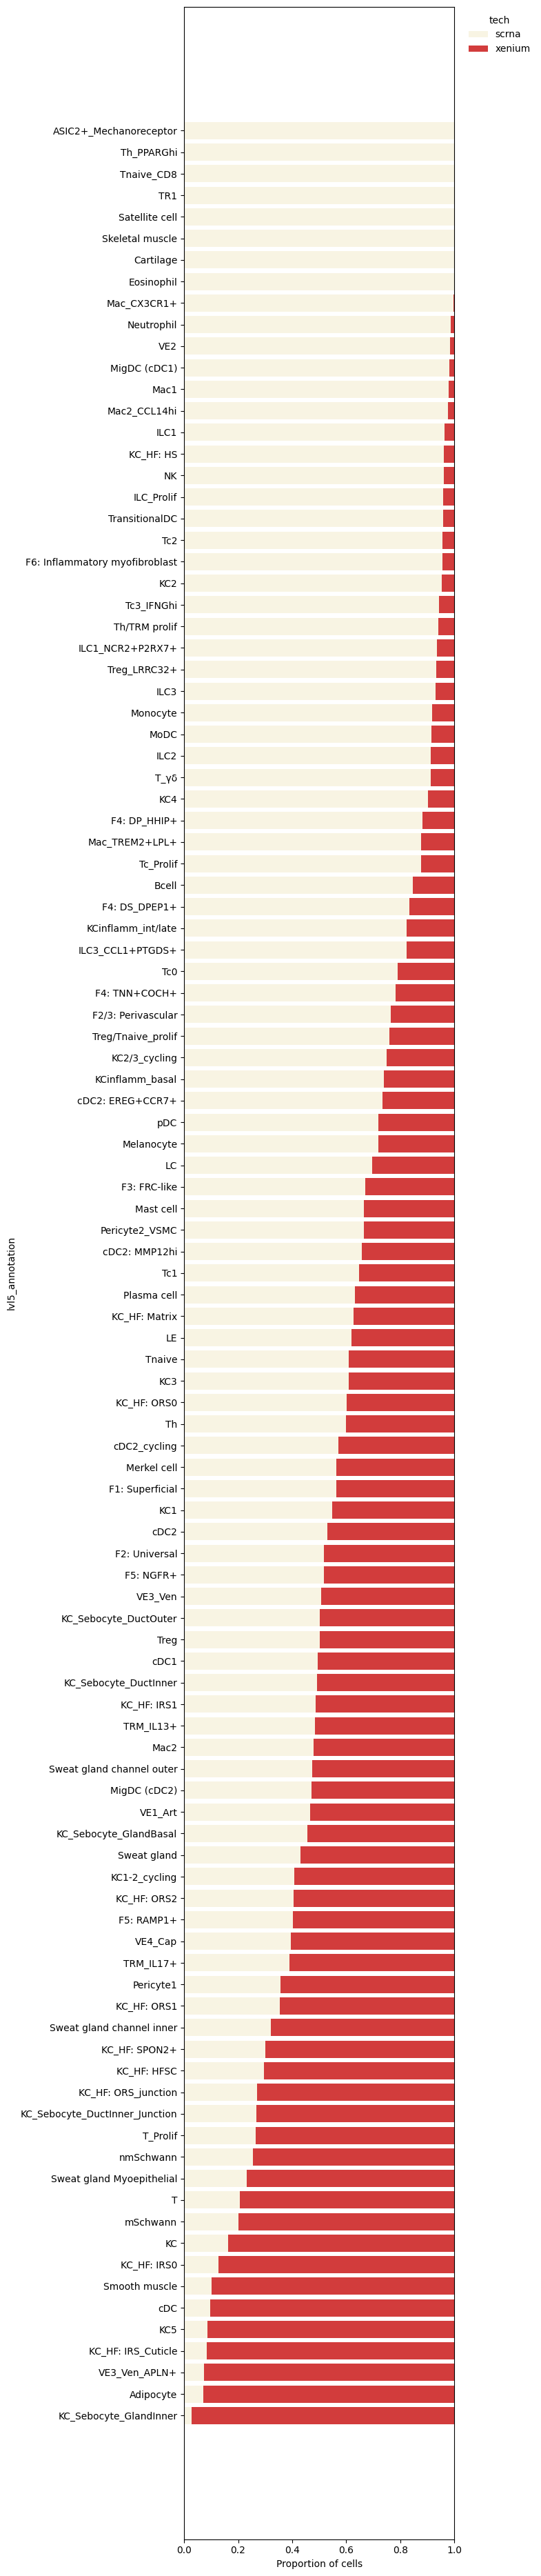

In [5]:
COLOR_DICT = { "scrna": "#F8F4E3",
             "xenium": "#D23C3C"
          }


# ----------------------------
# Build proportion table
# ----------------------------
df = adata.obs[["lvl5_annotation", "tech"]].copy()

# Count cells per (lvl5, tech)
counts = (
    df.groupby(["lvl5_annotation", "tech"])
    .size()
    .unstack(fill_value=0)
)

# Convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# ----------------------------
# Sort by % xenium (descending)
# ----------------------------
if "xenium" not in props.columns:
    raise ValueError("tech == 'xenium' not found in adata.obs['tech']")

props = props.sort_values(by="xenium", ascending=False)

# ----------------------------
# Plot horizontal stacked bars
# ----------------------------
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        label=tech,
    )
    left += props[tech]

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 1)

ax.legend(
    title="tech",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [6]:
# overall_props = (
#     adata.obs["tech"]
#     .value_counts(normalize=True)
# )

# xenium_frac = overall_props.get("xenium", 0.0)
# scrna_frac = overall_props.get("scrna", 0.0)



# # ----------------------------
# # Plot horizontal stacked bars
# # ----------------------------
# fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

# left = pd.Series(0, index=props.index)

# for tech in props.columns:
#     ax.barh(
#         props.index,
#         props[tech],
#         left=left,
#         color=COLOR_DICT.get(tech, "grey"),
#         label=tech,
#     )
#     left += props[tech]

# # ----------------------------
# # Add global proportion lines
# # ----------------------------
# ax.axvline(
#     xenium_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["xenium"],
#     label="Xenium proportion (overall)",
# )

# # ax.axvline(
# #     scrna_frac,
# #     linestyle=":",
# #     linewidth=2,
# #     color=COLOR_DICT["scrna"],
# #     label="overall scrna",
# # )

# # ----------------------------
# # Aesthetics
# # ----------------------------
# ax.set_xlabel("Proportion of cells")
# ax.set_ylabel("lvl5_annotation")
# ax.set_xlim(0, 1)

# ax.legend(
#     title="tech",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

# plt.tight_layout()
# plt.show()

In [7]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ----------------------------
# # Global proportions
# # ----------------------------
# overall_props = adata.obs["tech"].value_counts(normalize=True)

# xenium_frac = overall_props.get("xenium", 0.0)
# scrna_frac = overall_props.get("scrna", 0.0)

# # ----------------------------
# # Plot horizontal stacked bars
# # ----------------------------
# fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(props))))

# left = pd.Series(0, index=props.index)

# for tech in props.columns:
#     ax.barh(
#         props.index,
#         props[tech],
#         left=left,
#         color=COLOR_DICT.get(tech, "grey"),
#         edgecolor="black",
#         linewidth=0.3,     # fine outlines
#         label=tech,
#     )
#     left += props[tech]

# # ----------------------------
# # Add global proportion line
# # ----------------------------
# ax.axvline(
#     xenium_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["xenium"],
#     label="Xenium proportion (overall)",
# )

# # ----------------------------
# # Aesthetics / layout cleanup
# # ----------------------------
# ax.set_xlabel("Proportion of cells")
# ax.set_ylabel("lvl5_annotation")
# ax.set_xlim(0, 1)

# # Remove excess whitespace
# ax.set_ylim(-0.5, len(props) - 0.5)

# # Remove top/right spines
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# # Thin remaining spines
# ax.spines["left"].set_linewidth(0.5)
# ax.spines["bottom"].set_linewidth(0.5)

# # Legend outside
# ax.legend(
#     title="tech",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

# # Manual layout control (better than tight_layout here)
# plt.subplots_adjust(top=0.98, right=0.82)

# plt.show()

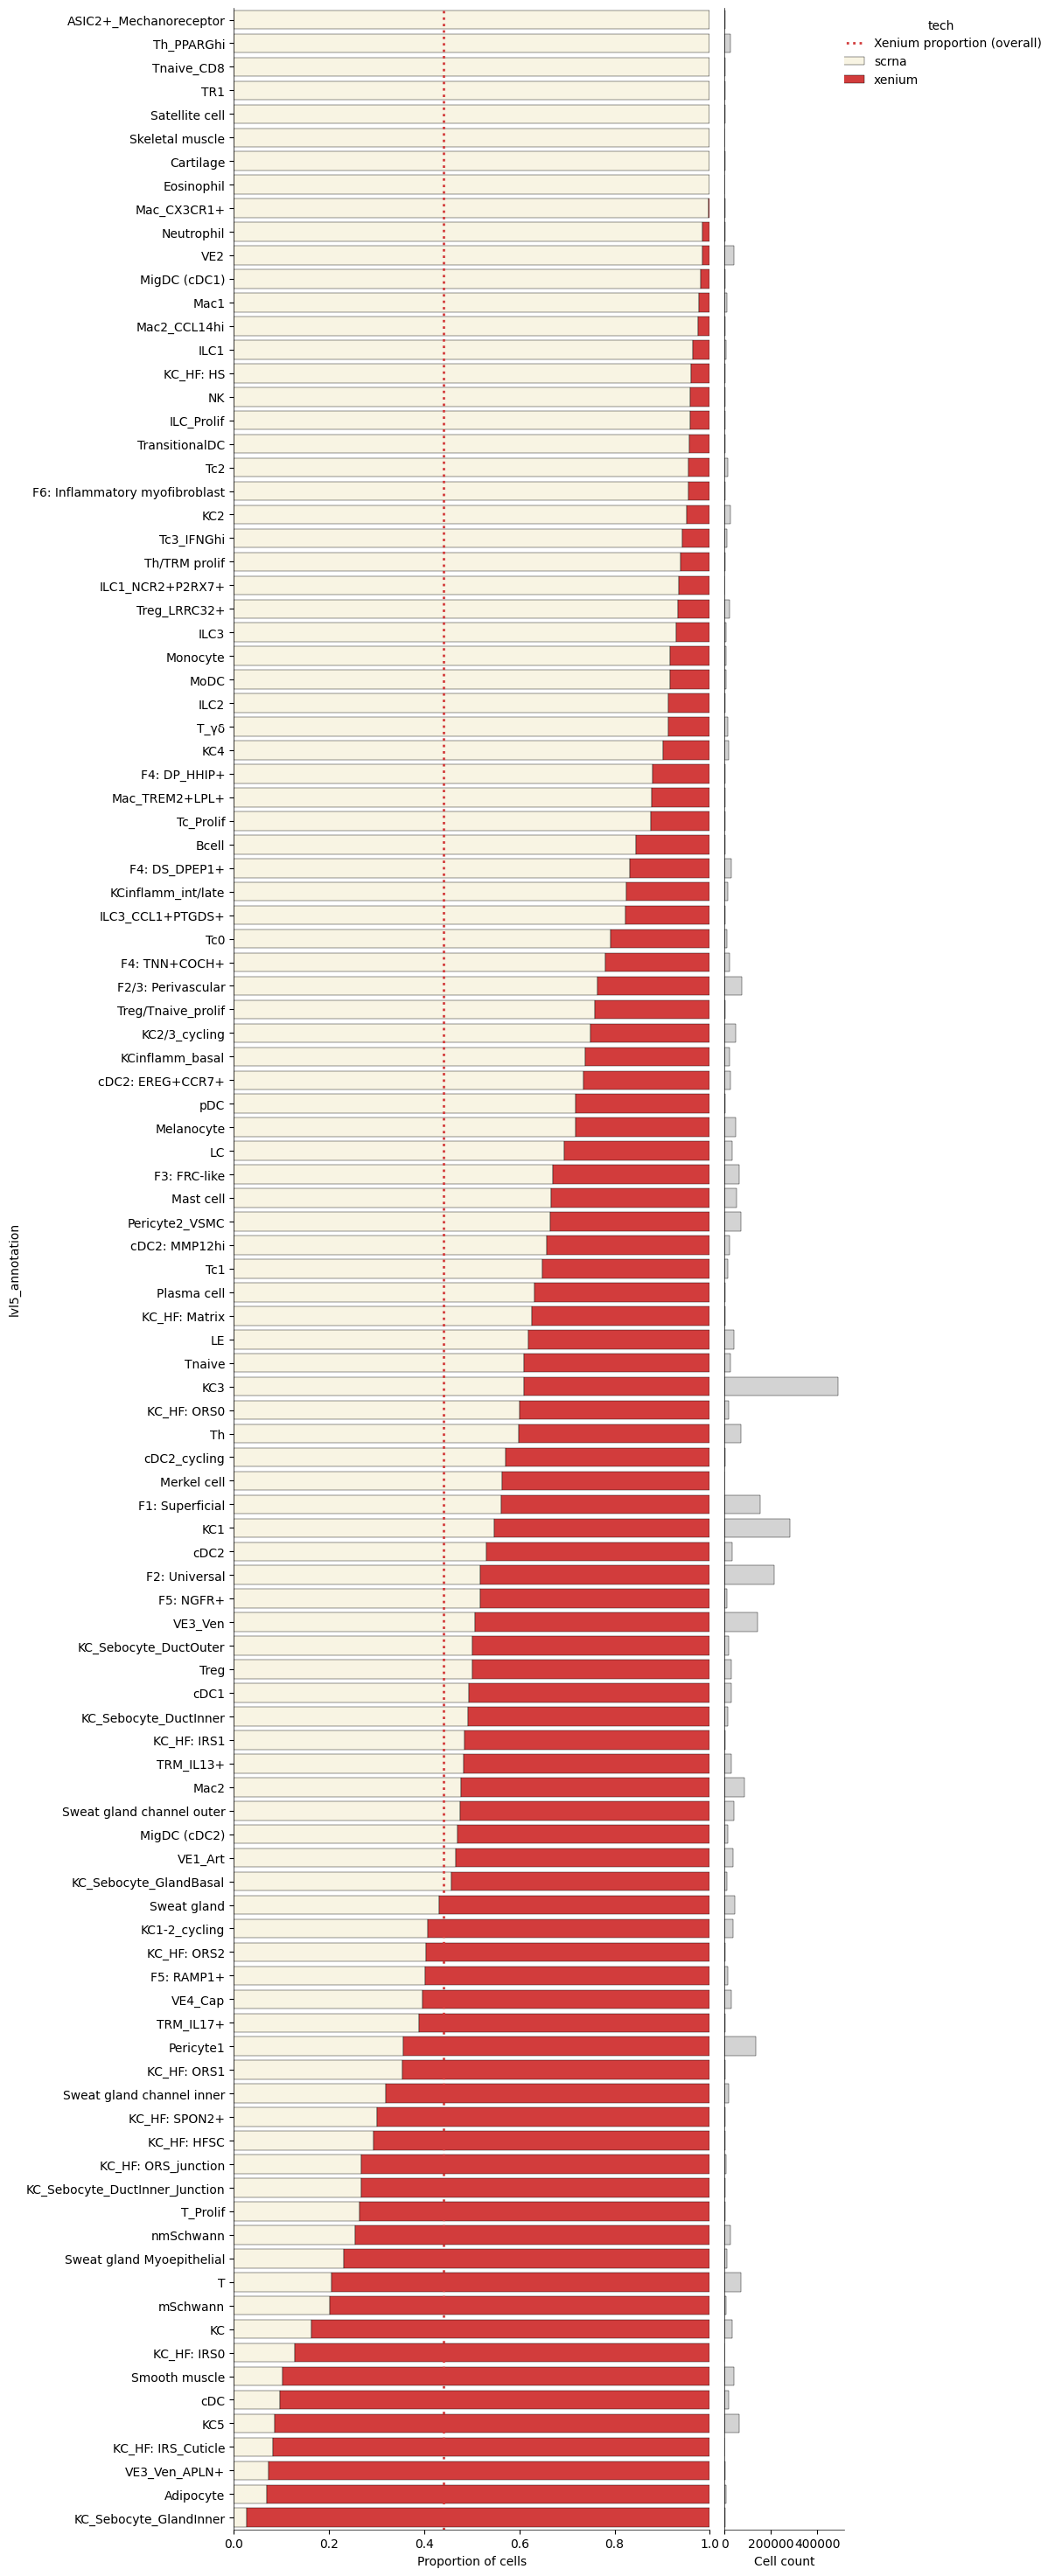

In [8]:

# ----------------------------
# Inputs / derived quantities
# ----------------------------
# props: DataFrame indexed by lvl5_annotation, columns = tech, values = proportions
# COLOR_DICT: mapping tech -> color

# Absolute counts per population
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)

# Global proportions
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Figure layout (shared y-axis)
# ----------------------------
fig = plt.figure(figsize=(9, max(4, 0.35 * len(props))))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax)

# ----------------------------
# Left: stacked proportions
# ----------------------------
left = pd.Series(0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
    )
    left += props[tech]

# Global xenium reference
ax.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)",
)

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")

# ----------------------------
# Right: abundance bars
# ----------------------------
ax_bar.barh(
    counts.index,
    counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
)

ax_bar.set_xlabel("Cell count")

# Remove duplicated y-axis clutter
ax_bar.tick_params(axis="y", left=False, labelleft=False)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax, ax_bar):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax.set_ylim(-0.5, len(props) - 0.5)

# Legend outside
ax.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False,
)

plt.show()

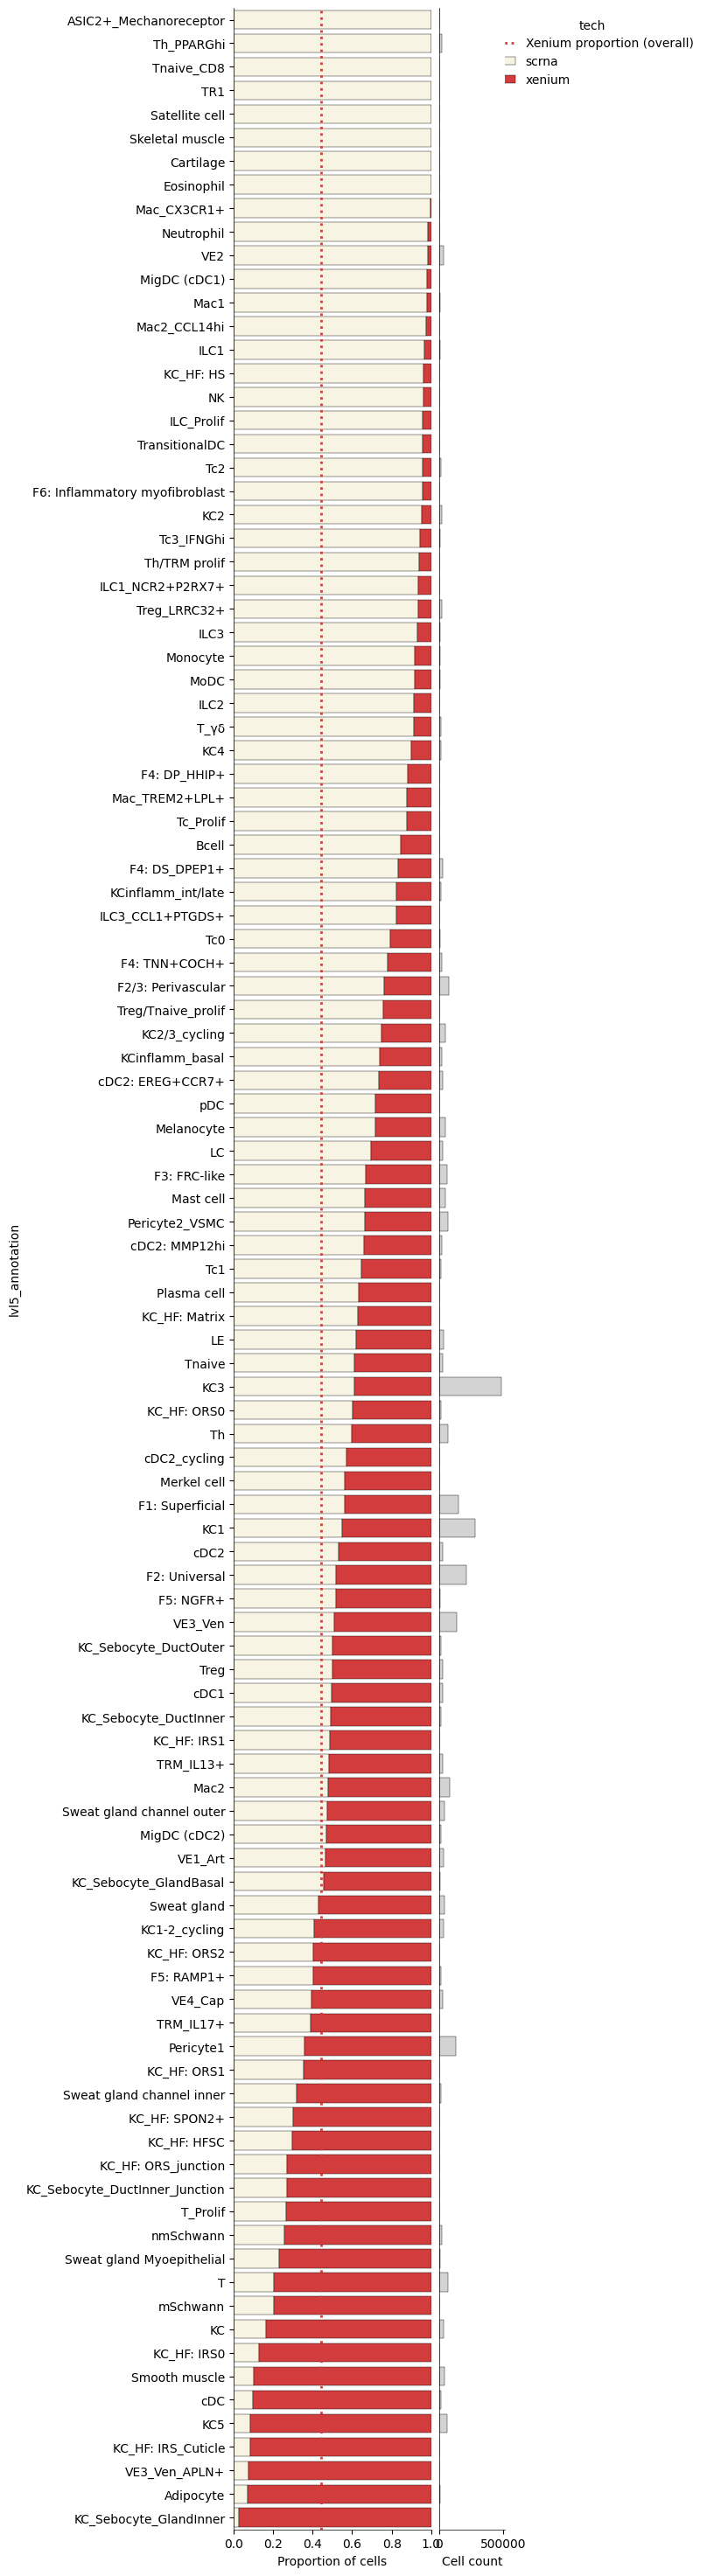

In [9]:
# ----------------------------
# Inputs / derived quantities
# ----------------------------
# props: DataFrame indexed by lvl5_annotation, columns = tech, values = proportions
# COLOR_DICT: mapping tech -> color

# Absolute counts per population
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)

# Global proportions
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Figure layout (NARROWER MAIN PANEL)
# ----------------------------
fig = plt.figure(figsize=(4, max(4, 0.35 * len(props))))  # ← narrower overall
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.06)       # ← main panel less wide

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax)

# ----------------------------
# Left: stacked proportions
# ----------------------------
left = pd.Series(0.0, index=props.index)

for tech in props.columns:
    ax.barh(
        props.index,
        props[tech],
        left=left,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
    )
    left += props[tech]

# Global xenium reference
ax.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)",
)

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")

# ----------------------------
# Right: abundance bars
# ----------------------------
ax_bar.barh(
    counts.index,
    counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
)

ax_bar.set_xlabel("Cell count")

# Remove duplicated y-axis clutter
ax_bar.tick_params(axis="y", left=False, labelleft=False)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax, ax_bar):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax.set_ylim(-0.5, len(props) - 0.5)

# Legend outside
ax.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False,
)

plt.show()




In [10]:
adata_i = adata[adata.obs["tech"] == "scrna"].copy()


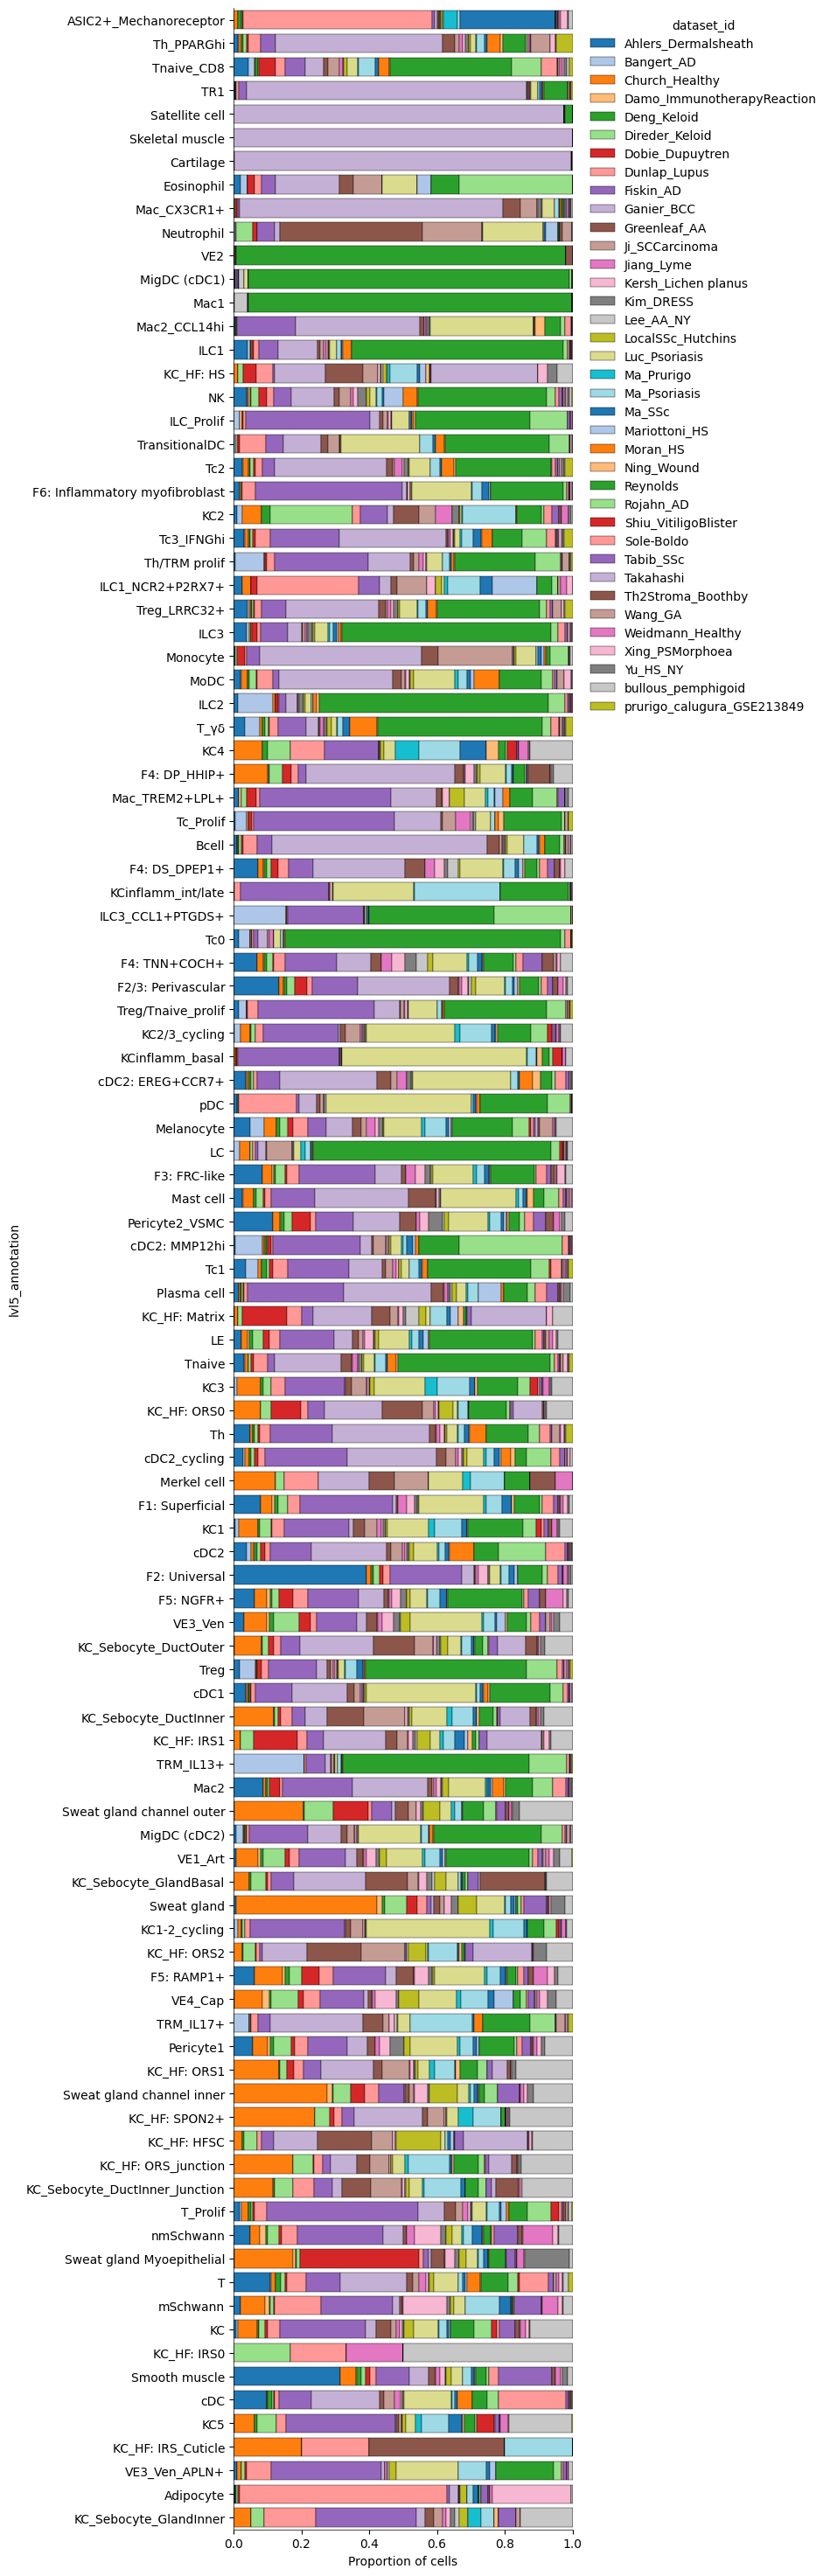

In [11]:
# Subset
df = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()

# Fixed y-axis order
y_order = props.index

# ----------------------------
# Compute proportions per lvl5_annotation
# ----------------------------
dataset_props = (
    df.groupby(["lvl5_annotation", "dataset_id"])
      .size()
      .unstack(fill_value=0)
)

# Normalize within each lvl5_annotation
dataset_props = dataset_props.div(dataset_props.sum(axis=1), axis=0).reindex(y_order).fillna(0)

# ----------------------------
# Filter out completely empty populations if you want
# ----------------------------
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# ----------------------------
# Color map for datasets
# ----------------------------
datasets = dataset_props.columns
cmap = plt.get_cmap("tab20")
dataset_colors = {d: cmap(i % cmap.N) for i, d in enumerate(datasets)}

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(5, max(4, 0.35 * len(dataset_props))))
left = pd.Series(0.0, index=dataset_props.index)

for d in datasets:
    ax.barh(
        dataset_props.index,
        dataset_props[d],
        left=left,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d
    )
    left += dataset_props[d]

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of cells")
ax.set_ylabel("lvl5_annotation")
ax.set_ylim(-0.5, len(dataset_props) - 0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()



In [12]:
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import pandas as pd
# #import glasbey

# # ----------------------------
# # Inputs / derived quantities
# # ----------------------------
# counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
# overall_props = adata.obs["tech"].value_counts(normalize=True)
# xenium_frac = overall_props.get("xenium", 0.0)

# # ----------------------------
# # Dataset proportions for Glasbey plot
# # ----------------------------
# df = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
# y_order = props.index

# dataset_props = (
#     df.groupby(["lvl5_annotation", "dataset_id"])
#       .size()
#       .unstack(fill_value=0)
# )
# dataset_props = (
#     dataset_props.div(dataset_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )
# dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# datasets = dataset_props.columns.tolist()
# palette = glasbey.create_palette(
#     palette_size=len(datasets),
#     lightness_bounds=(60, 100),
#     chroma_bounds=(0, 80)
# )
# dataset_colors = dict(zip(datasets, palette))

# # ----------------------------
# # Numeric y positions
# # ----------------------------
# y_pos = list(range(len(props)))

# # ----------------------------
# # Create combined figure
# # ----------------------------
# fig = plt.figure(figsize=(12, max(4, 0.35 * len(props))))
# gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# # --- Left: stacked proportions + abundance bars ---
# ax_left = fig.add_subplot(gs[0, 0])
# ax_bar = ax_left.twiny()  # secondary x-axis for abundance bars

# # Stacked proportion bars
# left_vals = [0.0] * len(props)
# for tech in props.columns:
#     ax_left.barh(
#         y=y_pos,
#         width=props[tech].values,
#         left=left_vals,
#         color=COLOR_DICT.get(tech, "grey"),
#         edgecolor="black",
#         linewidth=0.3,
#         label=tech,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# # Global Xenium reference
# ax_left.axvline(
#     xenium_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["xenium"],
#     label="Xenium proportion (overall)"
# )

# ax_left.set_xlim(0, 1)
# ax_left.set_xlabel("Proportion of cells")
# ax_left.set_ylabel("lvl5_annotation")
# ax_left.set_yticks(y_pos)
# ax_left.set_yticklabels(props.index)

# # Abundance bars (slightly shifted)
# ax_bar.barh(
#     y=[y - 0.175 for y in y_pos],  # shift down to not overlap proportion bars
#     width=counts.values,
#     color="lightgrey",
#     edgecolor="black",
#     linewidth=0.3,
#     alpha=0.7,
#     height=0.35
# )
# ax_bar.set_xlim(0, counts.max() * 1.1)
# ax_bar.set_xlabel("Cell count")
# ax_bar.set_yticks([])

# # ----------------------------
# # Right: dataset_id stacked proportions (Glasbey)
# # ----------------------------
# ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)
# left_vals = [0.0] * len(dataset_props)
# for d in datasets:
#     ax_right.barh(
#         y=y_pos,
#         width=dataset_props[d].values,
#         left=left_vals,
#         color=dataset_colors[d],
#         edgecolor="black",
#         linewidth=0.3,
#         label=d,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

# ax_right.set_xlim(0, 1)
# ax_right.set_xlabel("Proportion of cells")
# ax_right.tick_params(axis="y", labelleft=False, labelsize=7)

# # ----------------------------
# # Aesthetic cleanup
# # ----------------------------
# for a in (ax_left, ax_bar, ax_right):
#     a.spines["top"].set_visible(False)
#     a.spines["right"].set_visible(False)
#     a.spines["left"].set_linewidth(0.5)
#     a.spines["bottom"].set_linewidth(0.5)

# ax_left.set_ylim(-0.5, len(props) - 0.5)

# # Legends
# ax_left.legend(
#     title="tech",
#     bbox_to_anchor=(1.25, 1),
#     loc="upper left",
#     frameon=False
# )
# ax_right.legend(
#     title="dataset_id",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

In [13]:
# # ----------------------------
# # Subset and compute proportions
# # ----------------------------
# df = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
# y_order = props.index

# dataset_props = (
#     df.groupby(["lvl5_annotation", "dataset_id"])
#       .size()
#       .unstack(fill_value=0)
# )

# dataset_props = (
#     dataset_props
#     .div(dataset_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )

# dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# # ----------------------------
# # Glasbey colors (robust)
# # ----------------------------
# datasets = dataset_props.columns.tolist()
# palette = glasbey.create_palette(palette_size=len(datasets), lightness_bounds=(60, 100), chroma_bounds=(0, 80))  # ← generate n colors
# dataset_colors = dict(zip(datasets, palette))

# # ----------------------------
# # Plot
# # ----------------------------
# fig, ax = plt.subplots(
#     figsize=(5, max(4, 0.35 * len(dataset_props)))
# )

# left = pd.Series(0.0, index=dataset_props.index)

# for d in datasets:
#     ax.barh(
#         dataset_props.index,
#         dataset_props[d],
#         left=left,
#         color=dataset_colors[d],
#         edgecolor="black",
#         linewidth=0.3,
#         label=d
#     )
#     left += dataset_props[d]

# # ----------------------------
# # Aesthetics
# # ----------------------------
# ax.set_xlim(0, 1)
# ax.set_xlabel("Proportion of cells")
# ax.set_ylabel("lvl5_annotation")

# # Optionally shrink ytick font
# ax.tick_params(axis="y", labelsize=7)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_linewidth(0.5)
# ax.spines["bottom"].set_linewidth(0.5)

# ax.legend(
#     title="dataset_id",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

In [14]:
adata_ii = adata_i[~(adata_i.obs["Location"].str.startswith("GSM"))&
                   ~(adata_i.obs["Location"].str.startswith("PW"))&
                     ~(adata_i.obs["Location"].str.startswith("Curr"))&
                     ~(adata_i.obs["Location"].str.startswith("Bang"))&
                     ~(adata_i.obs["Location"].str.startswith("Roj"))&                     ~(adata_i.obs["Location"].str.startswith("Roj"))&
                     ~(adata_i.obs["Location"].str.startswith("bull"))&

                   ~(adata_i.obs["Location"].str.startswith("Miss"))
                  
                  ].copy()

In [15]:
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import pandas as pd
# import glasbey

# # ----------------------------
# # Inputs / derived quantities
# # ----------------------------
# counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
# overall_props = adata.obs["tech"].value_counts(normalize=True)
# xenium_frac = overall_props.get("xenium", 0.0)

# # ----------------------------
# # Dataset proportions for Glasbey plot
# # ----------------------------
# df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
# y_order = props.index

# dataset_props = (
#     df_dset.groupby(["lvl5_annotation", "dataset_id"])
#     .size()
#     .unstack(fill_value=0)
# )
# dataset_props = (
#     dataset_props.div(dataset_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )
# dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# datasets = dataset_props.columns.tolist()
# palette = glasbey.create_palette(
#     palette_size=len(datasets),
#     lightness_bounds=(60, 100),
#     chroma_bounds=(0, 80)
# )
# dataset_colors = dict(zip(datasets, palette))

# # ----------------------------
# # Location proportions for third panel
# # ----------------------------
# df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

# location_props = (
#     df_loc.groupby(["lvl5_annotation", "Location"])
#     .size()
#     .unstack(fill_value=0)
# )
# location_props = (
#     location_props.div(location_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )
# location_props = location_props.loc[location_props.sum(axis=1) > 0]

# locations = location_props.columns
# cmap = plt.get_cmap("tab20")
# location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# # ----------------------------
# # Numeric y positions
# # ----------------------------
# y_pos = list(range(len(props)))

# # ----------------------------
# # Create combined figure: 1 row × 3 columns
# # ----------------------------
# fig = plt.figure(figsize=(16, max(4, 0.35 * len(props))))
# gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.8)

# # --- Left: stacked proportions + abundance bars ---
# ax_left = fig.add_subplot(gs[0, 0])
# ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# # Stacked proportion bars
# left_vals = [0.0] * len(props)
# for tech in props.columns:
#     ax_left.barh(
#         y=y_pos,
#         width=props[tech].values,
#         left=left_vals,
#         color=COLOR_DICT.get(tech, "grey"),
#         edgecolor="black",
#         linewidth=0.3,
#         label=tech,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# # Xenium reference
# ax_left.axvline(
#     xenium_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["xenium"],
#     label="Xenium proportion (overall)"
# )

# ax_left.set_xlim(0, 1)
# ax_left.set_xlabel("Proportion of cells")
# ax_left.set_ylabel("lvl5_annotation")
# ax_left.set_yticks(y_pos)
# ax_left.set_yticklabels(props.index)

# # Abundance bars (shifted slightly)
# ax_bar.barh(
#     y=[y - 0.175 for y in y_pos],
#     width=counts.values,
#     color="lightgrey",
#     edgecolor="black",
#     linewidth=0.3,
#     alpha=0.7,
#     height=0.35
# )
# ax_bar.set_xlim(0, counts.max() * 1.1)
# ax_bar.set_xlabel("Cell count")
# ax_bar.set_yticks([])

# # --- Middle: dataset_id stacked proportions (Glasbey) ---
# ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
# left_vals = [0.0] * len(dataset_props)
# for d in datasets:
#     ax_middle.barh(
#         y=y_pos,
#         width=dataset_props[d].values,
#         left=left_vals,
#         color=dataset_colors[d],
#         edgecolor="black",
#         linewidth=0.3,
#         label=d,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

# ax_middle.set_xlim(0, 1)
# ax_middle.set_xlabel("Proportion of cells")
# ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)

# # --- Right: Location stacked proportions ---
# ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
# left_vals = [0.0] * len(location_props)
# for l in locations:
#     ax_right.barh(
#         y=y_pos,
#         width=location_props[l].values,
#         left=left_vals,
#         color=location_colors[l],
#         edgecolor="black",
#         linewidth=0.3,
#         label=l,
#         height=0.7
#     )
#     left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

# ax_right.set_xlim(0, 1)
# ax_right.set_xlabel("Proportion of cells")
# ax_right.tick_params(axis="y", labelleft=False, labelsize=7)

# # ----------------------------
# # Aesthetic cleanup
# # ----------------------------
# for a in (ax_left, ax_bar, ax_middle, ax_right):
#     a.spines["top"].set_visible(False)
#     a.spines["right"].set_visible(False)
#     a.spines["left"].set_linewidth(0.5)
#     a.spines["bottom"].set_linewidth(0.5)

# ax_left.set_ylim(-0.5, len(props) - 0.5)

# # Legends
# ax_left.legend(
#     title="tech",
#     bbox_to_anchor=(1.25, 1),
#     loc="upper left",
#     frameon=False
# )
# ax_middle.legend(
#     title="dataset_id",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )
# ax_right.legend(
#     title="Location",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

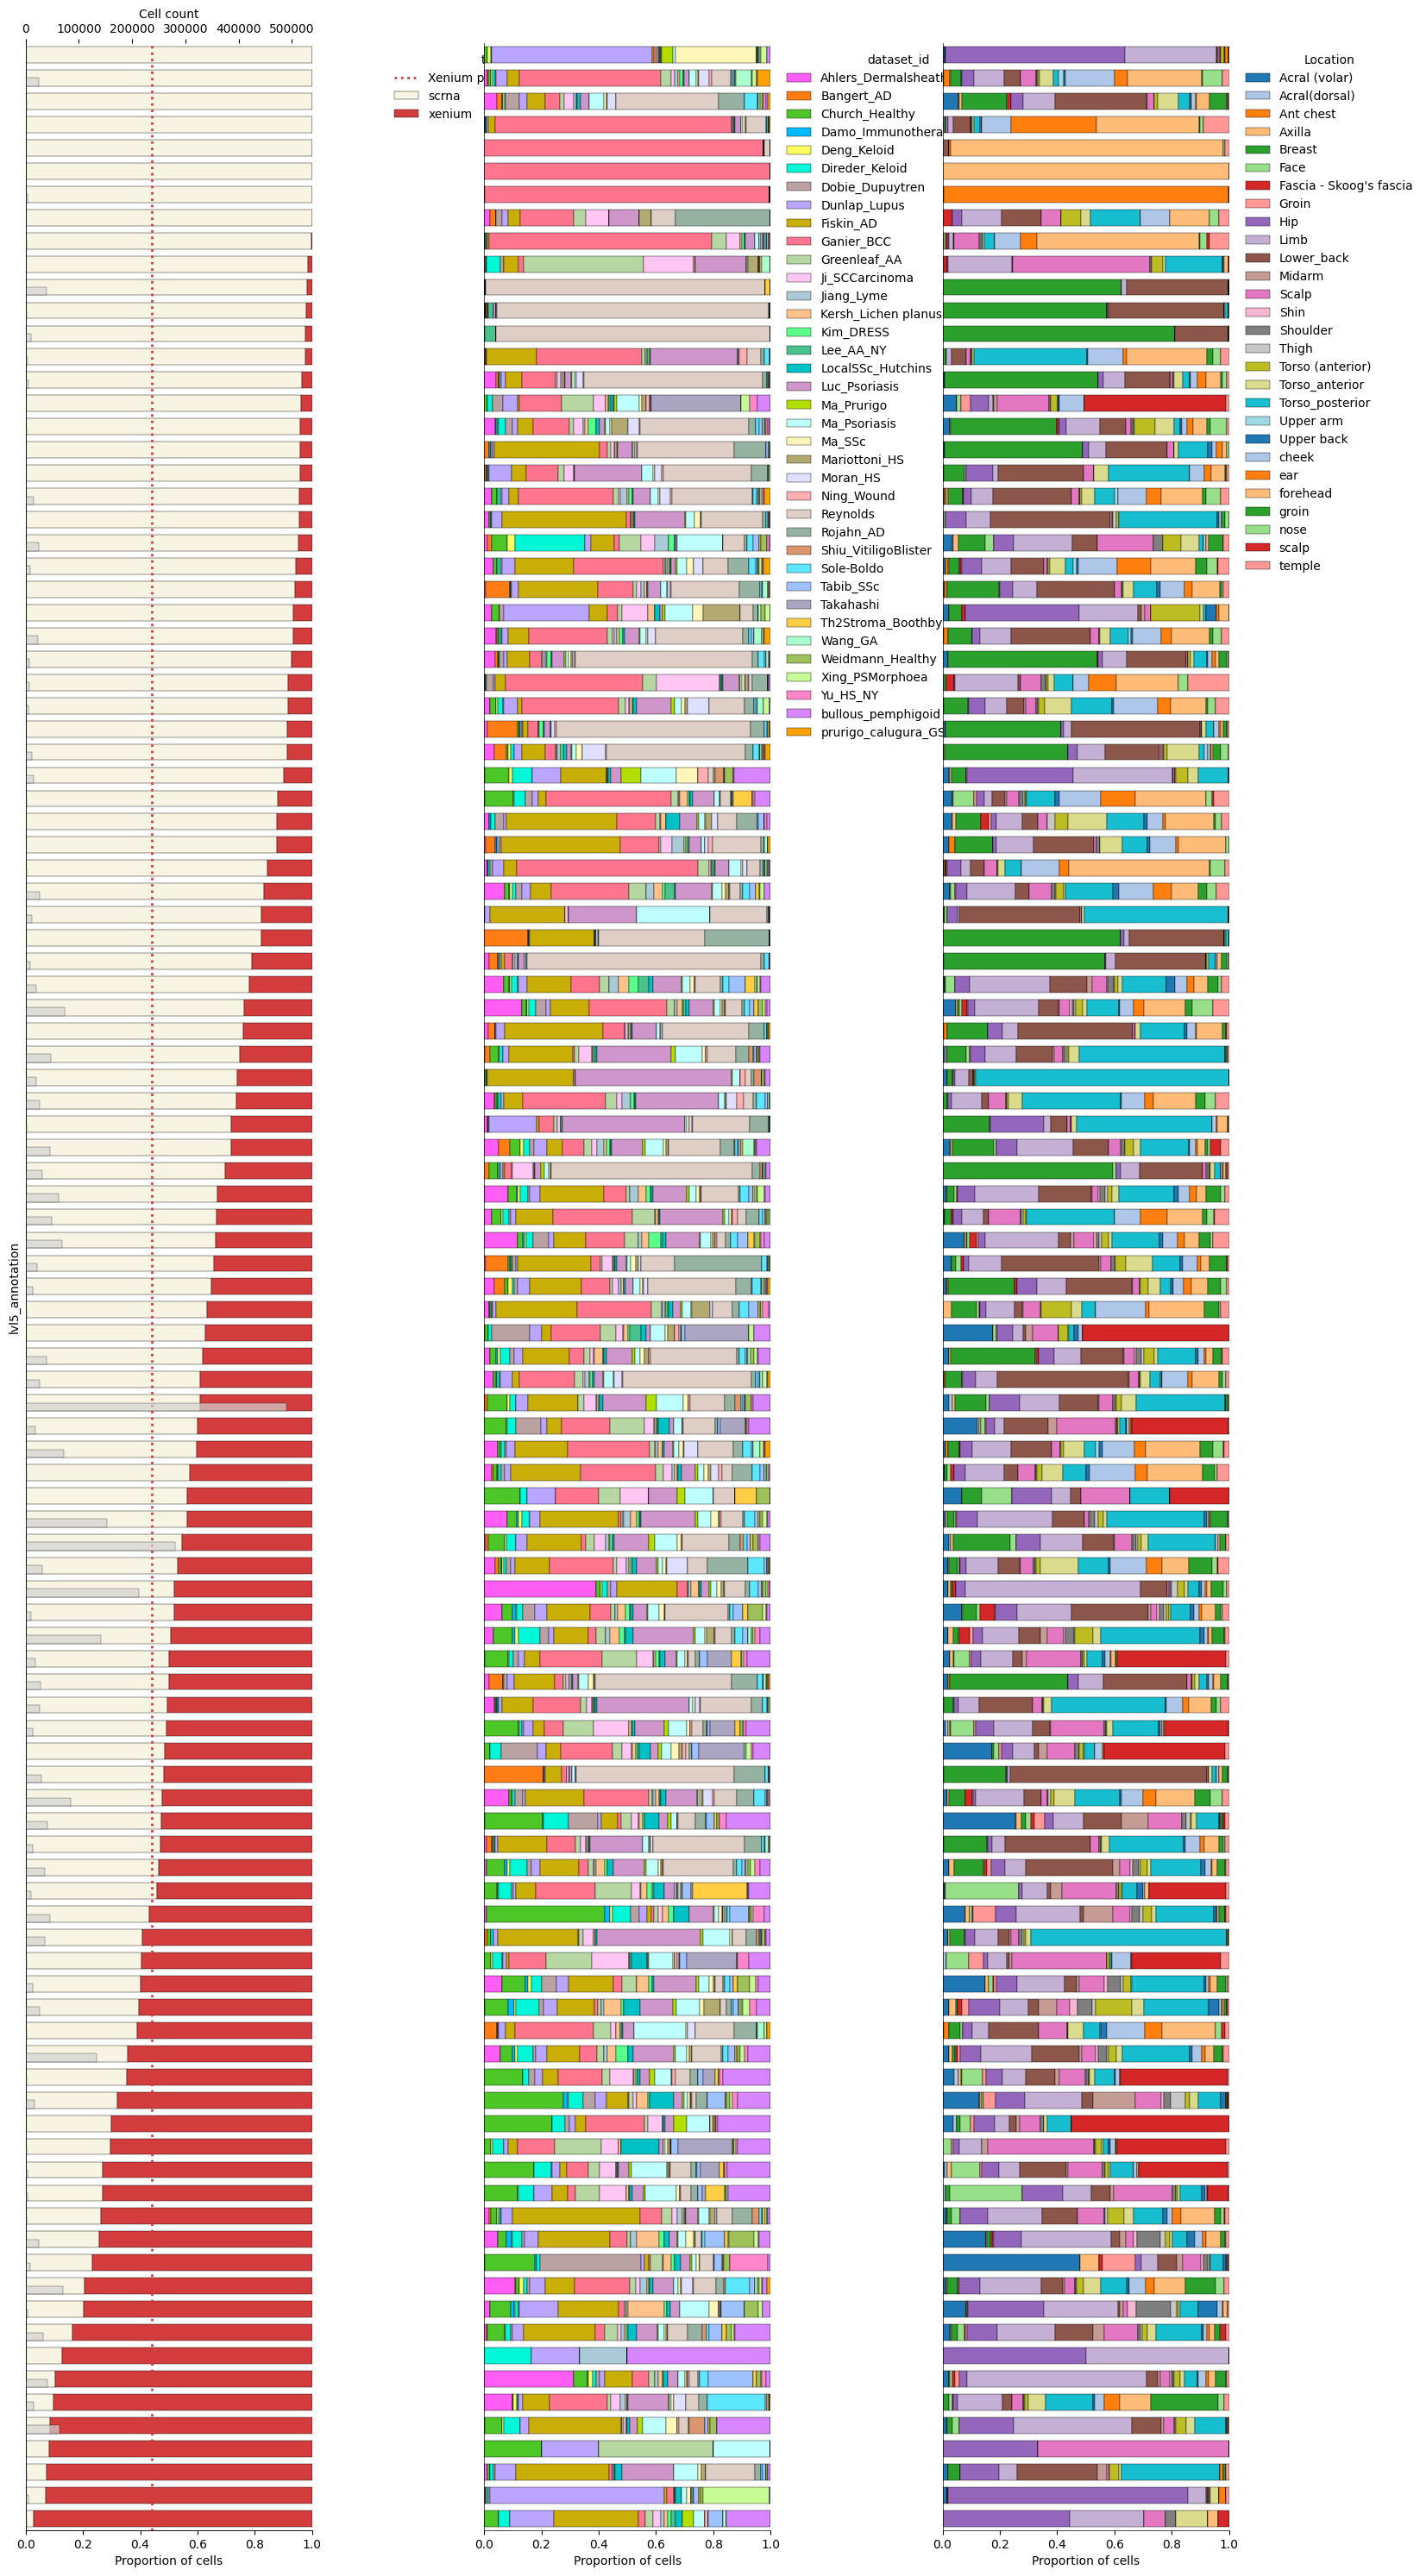

In [16]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import glasbey

# ----------------------------
# Inputs / derived quantities
# ----------------------------
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Dataset proportions for Glasbey plot
# ----------------------------
df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
y_order = props.index

dataset_props = (
    df_dset.groupby(["lvl5_annotation", "dataset_id"])
    .size()
    .unstack(fill_value=0)
)
dataset_props = (
    dataset_props.div(dataset_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

datasets = dataset_props.columns.tolist()
palette = glasbey.create_palette(
    palette_size=len(datasets),
    lightness_bounds=(60, 100),
    chroma_bounds=(0, 80)
)
dataset_colors = dict(zip(datasets, palette))

# ----------------------------
# Location proportions for third panel
# ----------------------------
df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

location_props = (
    df_loc.groupby(["lvl5_annotation", "Location"])
    .size()
    .unstack(fill_value=0)
)
location_props = (
    location_props.div(location_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
location_props = location_props.loc[location_props.sum(axis=1) > 0]

locations = location_props.columns
cmap = plt.get_cmap("tab20")
location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# ----------------------------
# Numeric y positions
# ----------------------------
y_pos = list(range(len(props)))

# ----------------------------
# Create combined figure: 1 row × 3 columns
# ----------------------------
fig = plt.figure(
    figsize=(18, max(4, 0.35 * len(props)))  # slightly wider for all legends
)
gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.6)  # more space between middle and right

# --- Left: stacked proportions + abundance bars ---
ax_left = fig.add_subplot(gs[0, 0])
ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# Stacked proportion bars
left_vals = [0.0] * len(props)
for tech in props.columns:
    ax_left.barh(
        y=y_pos,
        width=props[tech].values,
        left=left_vals,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# Xenium reference
ax_left.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)"
)

ax_left.set_xlim(0, 1)
ax_left.set_xlabel("Proportion of cells")
ax_left.set_ylabel("lvl5_annotation")
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(props.index)

# Abundance bars: slightly shifted
ax_bar.barh(
    y=[y - 0.175 for y in y_pos],
    width=counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.7,
    height=0.35
)
ax_bar.set_xlim(0, counts.max() * 1.1)
ax_bar.set_xlabel("Cell count")
ax_bar.set_yticks([])

# --- Middle: dataset_id stacked proportions (Glasbey) ---
ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
left_vals = [0.0] * len(dataset_props)
for d in datasets:
    ax_middle.barh(
        y=y_pos,
        width=dataset_props[d].values,
        left=left_vals,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

ax_middle.set_xlim(0, 1)
ax_middle.set_xlabel("Proportion of cells")
ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)

# --- Right: Location stacked proportions ---
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
left_vals = [0.0] * len(location_props)
for l in locations:
    ax_right.barh(
        y=y_pos,
        width=location_props[l].values,
        left=left_vals,
        color=location_colors[l],
        edgecolor="black",
        linewidth=0.3,
        label=l,
        height=0.7
    )
    left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

ax_right.set_xlim(0, 1)
ax_right.set_xlabel("Proportion of cells")
ax_right.tick_params(axis="y", labelleft=False, labelsize=7)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax_left, ax_bar, ax_middle, ax_right):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax_left.set_ylim(-0.5, len(props) - 0.5)

# Legends
ax_left.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False
)
ax_middle.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
ax_right.legend(
    title="Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

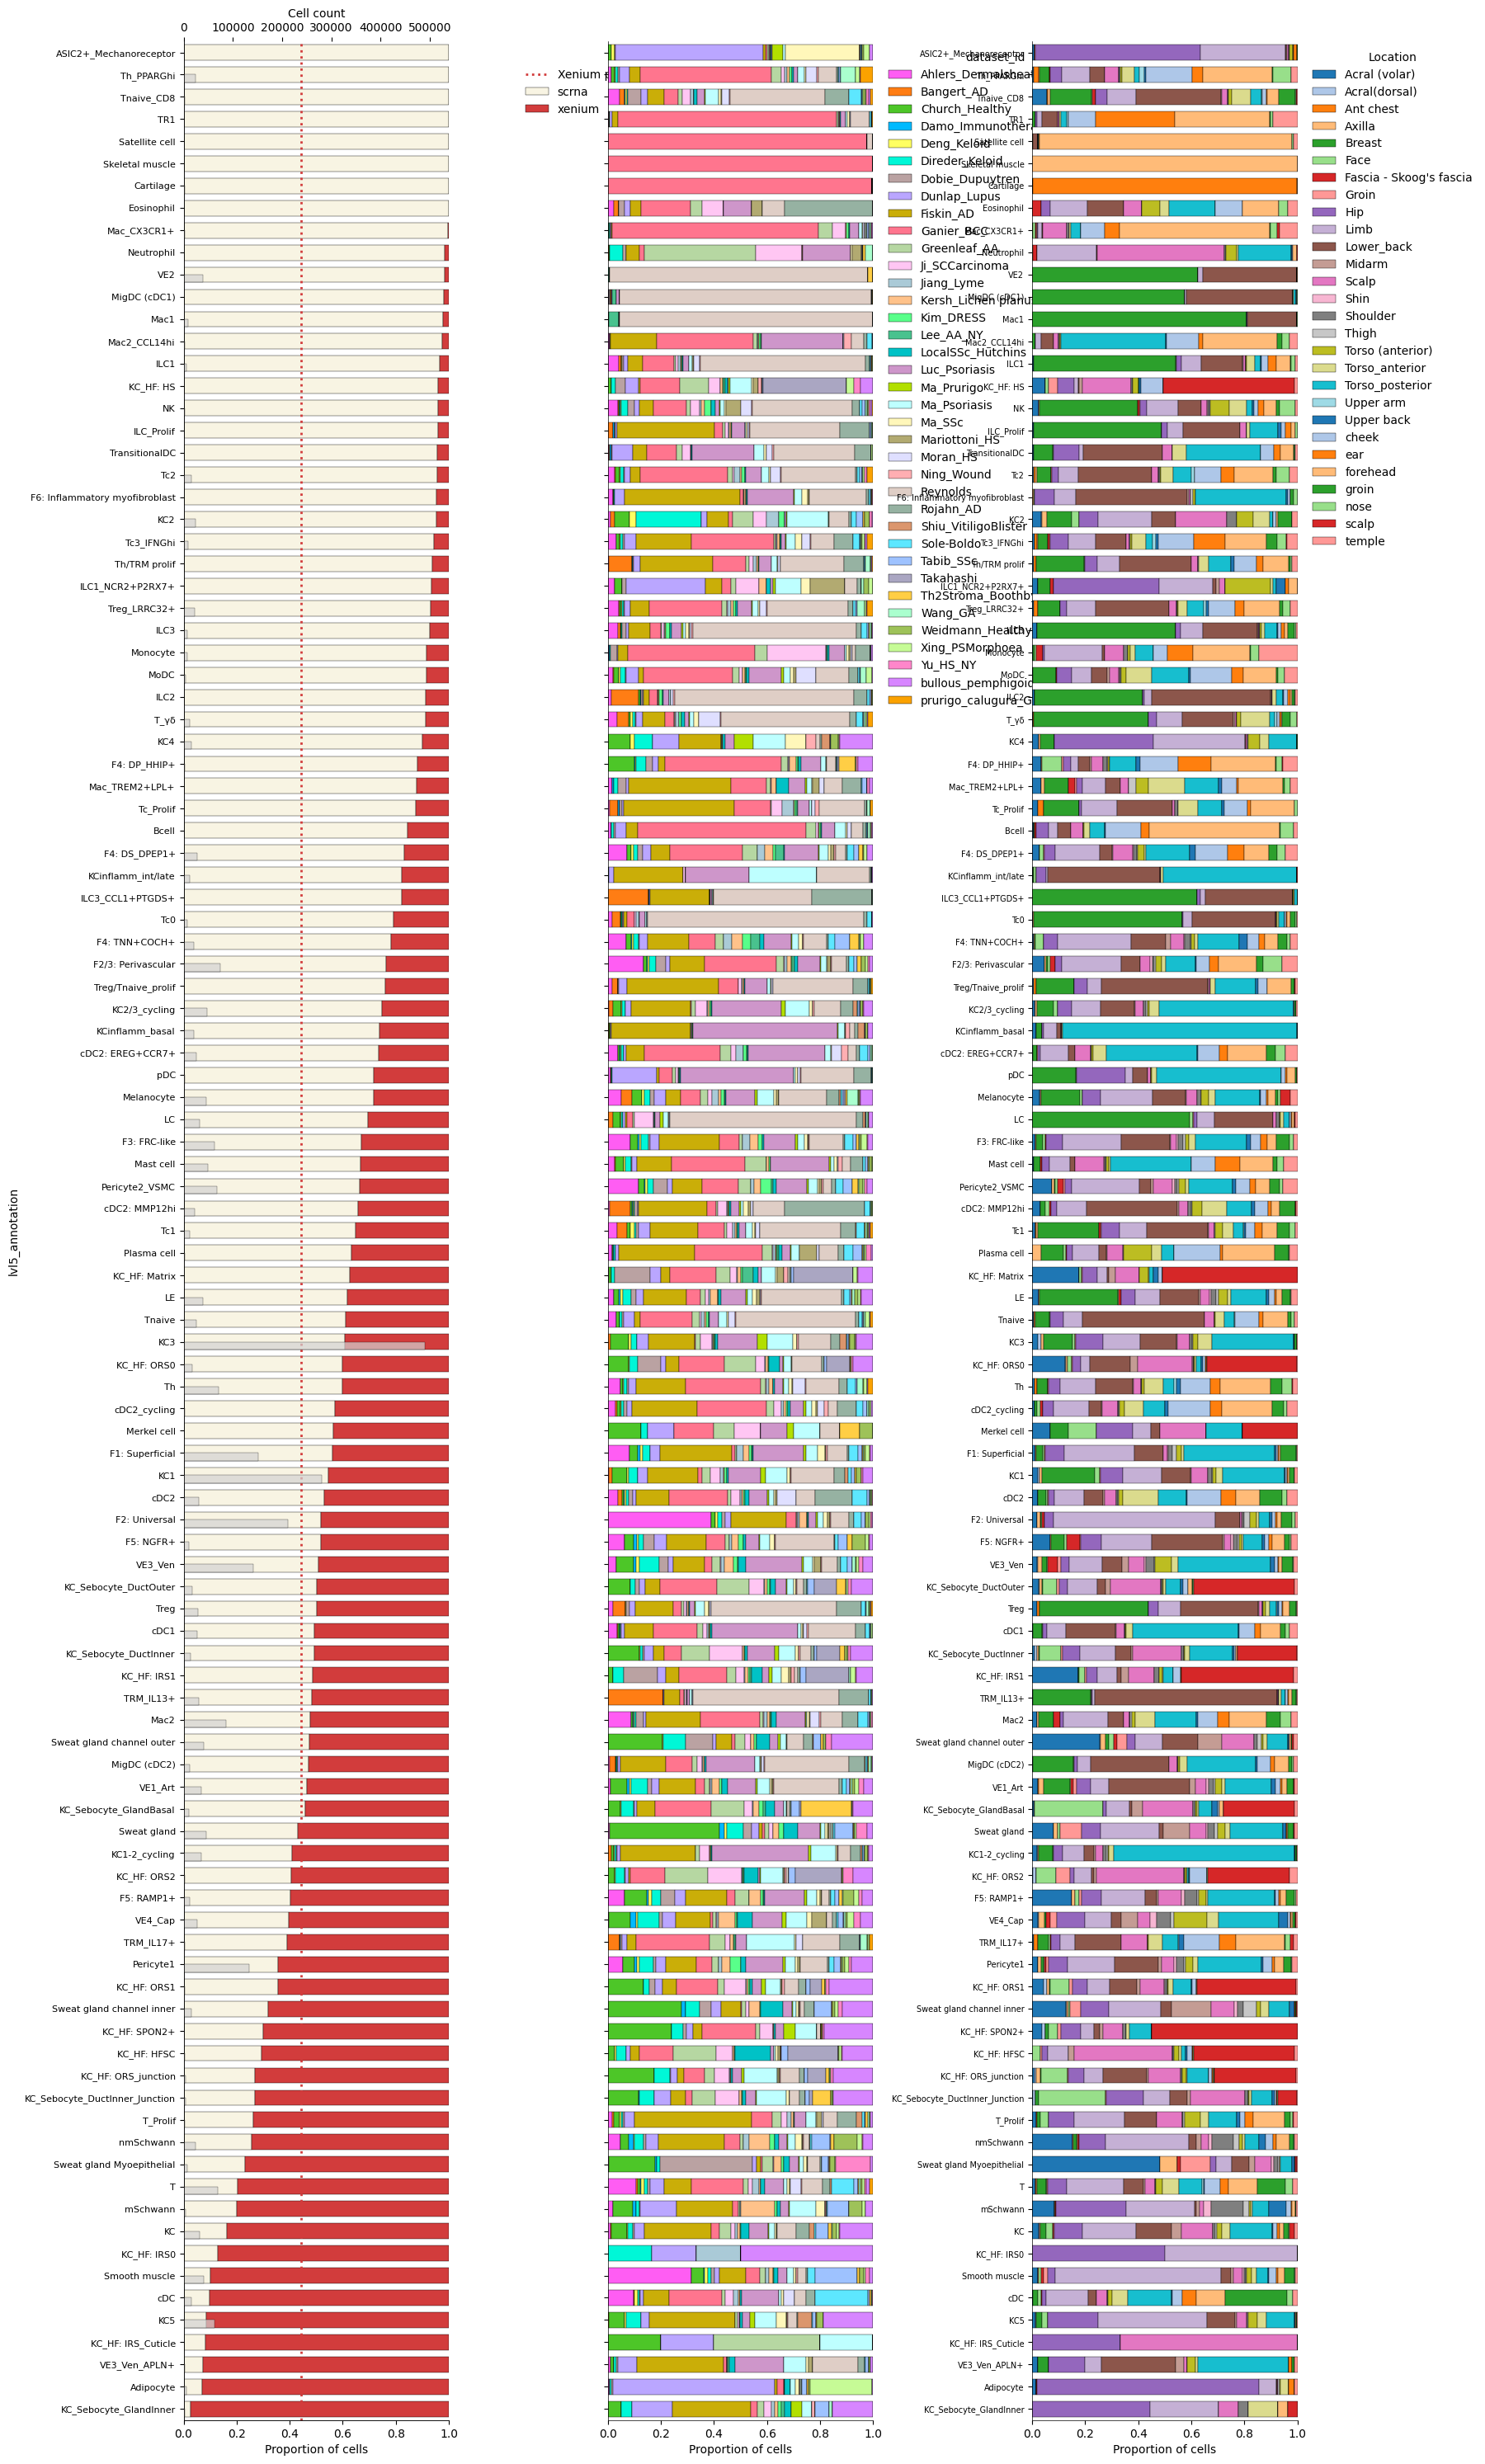

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import glasbey

# ----------------------------
# Inputs / derived quantities
# ----------------------------
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Dataset proportions for Glasbey plot
# ----------------------------
df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
y_order = props.index

dataset_props = (
    df_dset.groupby(["lvl5_annotation", "dataset_id"])
    .size()
    .unstack(fill_value=0)
)
dataset_props = (
    dataset_props.div(dataset_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

datasets = dataset_props.columns.tolist()
palette = glasbey.create_palette(
    palette_size=len(datasets),
    lightness_bounds=(60, 100),
    chroma_bounds=(0, 80)
)
dataset_colors = dict(zip(datasets, palette))

# ----------------------------
# Location proportions for third panel
# ----------------------------
df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

location_props = (
    df_loc.groupby(["lvl5_annotation", "Location"])
    .size()
    .unstack(fill_value=0)
)
location_props = (
    location_props.div(location_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
location_props = location_props.loc[location_props.sum(axis=1) > 0]

locations = location_props.columns
cmap = plt.get_cmap("tab20")
location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# ----------------------------
# Numeric y positions
# ----------------------------
y_pos = list(range(len(props)))

# ----------------------------
# Create combined figure: 1 row × 3 columns
# ----------------------------
fig = plt.figure(
    figsize=(18, max(4, 0.35 * len(props)))  # slightly wider for all legends
)
gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.6)  # more space between middle and right

# --- Left: stacked proportions + abundance bars ---
ax_left = fig.add_subplot(gs[0, 0])
ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# Stacked proportion bars
left_vals = [0.0] * len(props)
for tech in props.columns:
    ax_left.barh(
        y=y_pos,
        width=props[tech].values,
        left=left_vals,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# Xenium reference
ax_left.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)"
)

ax_left.set_xlim(0, 1)
ax_left.set_xlabel("Proportion of cells")
ax_left.set_ylabel("lvl5_annotation")
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(props.index)


# After creating the figure, before tight_layout:
fig.subplots_adjust(left=0.15)  # increase left margin so yticks are visible

# Ensure left y-axis ticks and labels are on
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(props.index, fontsize=8)
ax_left.tick_params(axis="y", which="both", left=True, labelleft=True)
# Abundance bars: slightly shifted
ax_bar.barh(
    y=[y - 0.175 for y in y_pos],
    width=counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.7,
    height=0.35
)
ax_bar.set_xlim(0, counts.max() * 1.1)
ax_bar.set_xlabel("Cell count")
ax_bar.set_yticks([])

# --- Middle: dataset_id stacked proportions (Glasbey) ---
ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
left_vals = [0.0] * len(dataset_props)
for d in datasets:
    ax_middle.barh(
        y=y_pos,
        width=dataset_props[d].values,
        left=left_vals,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

ax_middle.set_xlim(0, 1)
ax_middle.set_xlabel("Proportion of cells")
ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)

# --- Right: Location stacked proportions ---
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
left_vals = [0.0] * len(location_props)
for l in locations:
    ax_right.barh(
        y=y_pos,
        width=location_props[l].values,
        left=left_vals,
        color=location_colors[l],
        edgecolor="black",
        linewidth=0.3,
        label=l,
        height=0.7
    )
    left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

ax_right.set_xlim(0, 1)
ax_right.set_xlabel("Proportion of cells")
# Show y-tick labels on the right panel
ax_right.set_yticks(y_pos)
ax_right.set_yticklabels(props.index, fontsize=7)

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax_left, ax_bar, ax_middle, ax_right):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax_left.set_ylim(-0.5, len(props) - 0.5)

# Legends
ax_left.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False
)
ax_middle.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
ax_right.legend(
    title="Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig("basic_qc_metric_final_ytick.pdf", dpi=300, bbox_inches="tight")

plt.show()



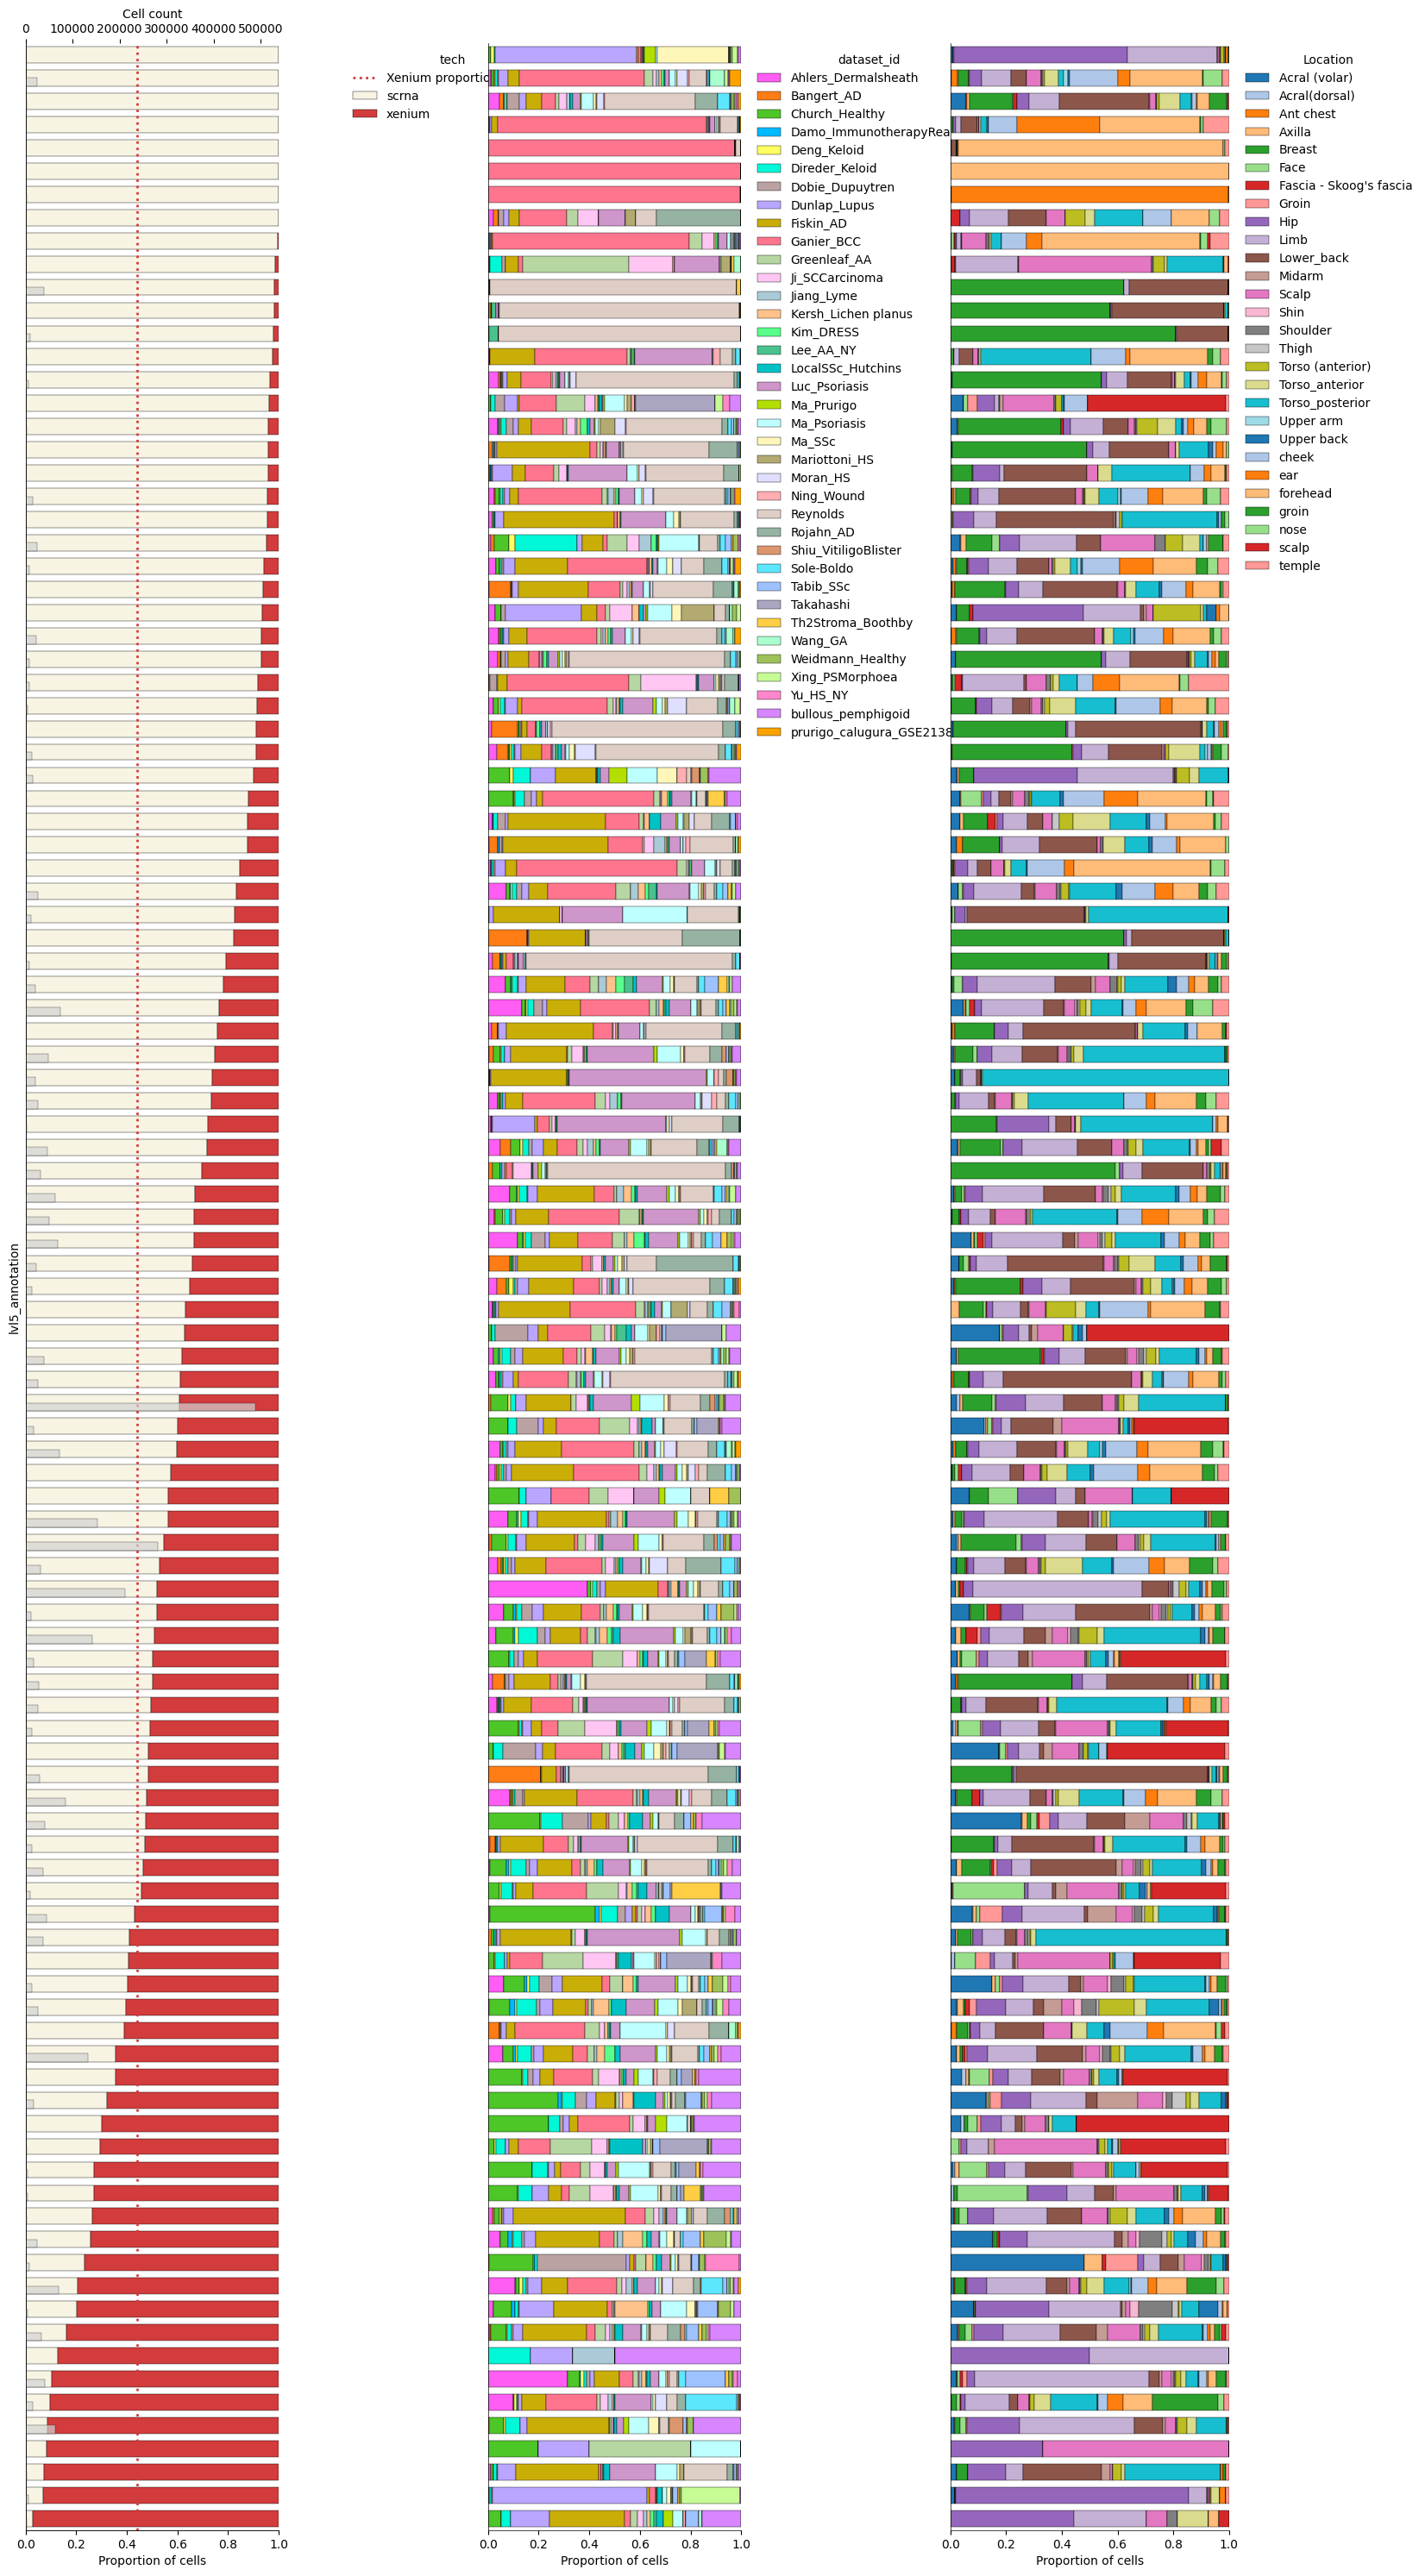

In [18]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import glasbey

# ----------------------------
# Inputs / derived quantities
# ----------------------------
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Dataset proportions for Glasbey plot
# ----------------------------
df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
y_order = props.index

dataset_props = (
    df_dset.groupby(["lvl5_annotation", "dataset_id"])
    .size()
    .unstack(fill_value=0)
)
dataset_props = (
    dataset_props.div(dataset_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

datasets = dataset_props.columns.tolist()
palette = glasbey.create_palette(
    palette_size=len(datasets),
    lightness_bounds=(60, 100),
    chroma_bounds=(0, 80)
)
dataset_colors = dict(zip(datasets, palette))

# ----------------------------
# Location proportions for third panel
# ----------------------------
df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

location_props = (
    df_loc.groupby(["lvl5_annotation", "Location"])
    .size()
    .unstack(fill_value=0)
)
location_props = (
    location_props.div(location_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
location_props = location_props.loc[location_props.sum(axis=1) > 0]

locations = location_props.columns
cmap = plt.get_cmap("tab20")
location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# ----------------------------
# Numeric y positions
# ----------------------------
y_pos = list(range(len(props)))

# ----------------------------
# Create combined figure: 1 row × 3 columns
# ----------------------------
fig = plt.figure(
    figsize=(18, max(4, 0.35 * len(props)))  # slightly wider for all legends
)

# Adjusted GridSpec: right plot slightly wider, more spacing
gs = GridSpec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.8)

# --- Left: stacked proportions + abundance bars ---
ax_left = fig.add_subplot(gs[0, 0])
ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# Stacked proportion bars
left_vals = [0.0] * len(props)
for tech in props.columns:
    ax_left.barh(
        y=y_pos,
        width=props[tech].values,
        left=left_vals,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# Xenium reference
ax_left.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)"
)

ax_left.set_xlim(0, 1)
ax_left.set_xlabel("Proportion of cells")
ax_left.set_ylabel("lvl5_annotation")
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(props.index, fontsize=8)
ax_left.tick_params(axis="y", which="both", left=True, labelleft=True)

# Abundance bars: slightly shifted
ax_bar.barh(
    y=[y - 0.175 for y in y_pos],
    width=counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.7,
    height=0.35
)
ax_bar.set_xlim(0, counts.max() * 1.1)
ax_bar.set_xlabel("Cell count")
ax_bar.set_yticks([])

# --- Middle: dataset_id stacked proportions (Glasbey) ---
ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
left_vals = [0.0] * len(dataset_props)
for d in datasets:
    ax_middle.barh(
        y=y_pos,
        width=dataset_props[d].values,
        left=left_vals,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

ax_middle.set_xlim(0, 1)
ax_middle.set_xlabel("Proportion of cells")
ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)

# --- Right: Location stacked proportions ---
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
left_vals = [0.0] * len(location_props)
for l in locations:
    ax_right.barh(
        y=y_pos,
        width=location_props[l].values,
        left=left_vals,
        color=location_colors[l],
        edgecolor="black",
        linewidth=0.3,
        label=l,
        height=0.7
    )
    left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

ax_right.set_xlim(0, 1)
ax_right.set_xlabel("Proportion of cells")

# Remove y-ticks and labels on right plot
ax_right.set_yticks([])
ax_right.set_yticklabels([])

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax_left, ax_bar, ax_middle, ax_right):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax_left.set_ylim(-0.5, len(props) - 0.5)

# Legends
ax_left.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False
)
ax_middle.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
ax_right.legend(
    title="Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig("basic_qc_metric_final_noytick.pdf", dpi=300, bbox_inches="tight")

plt.show()

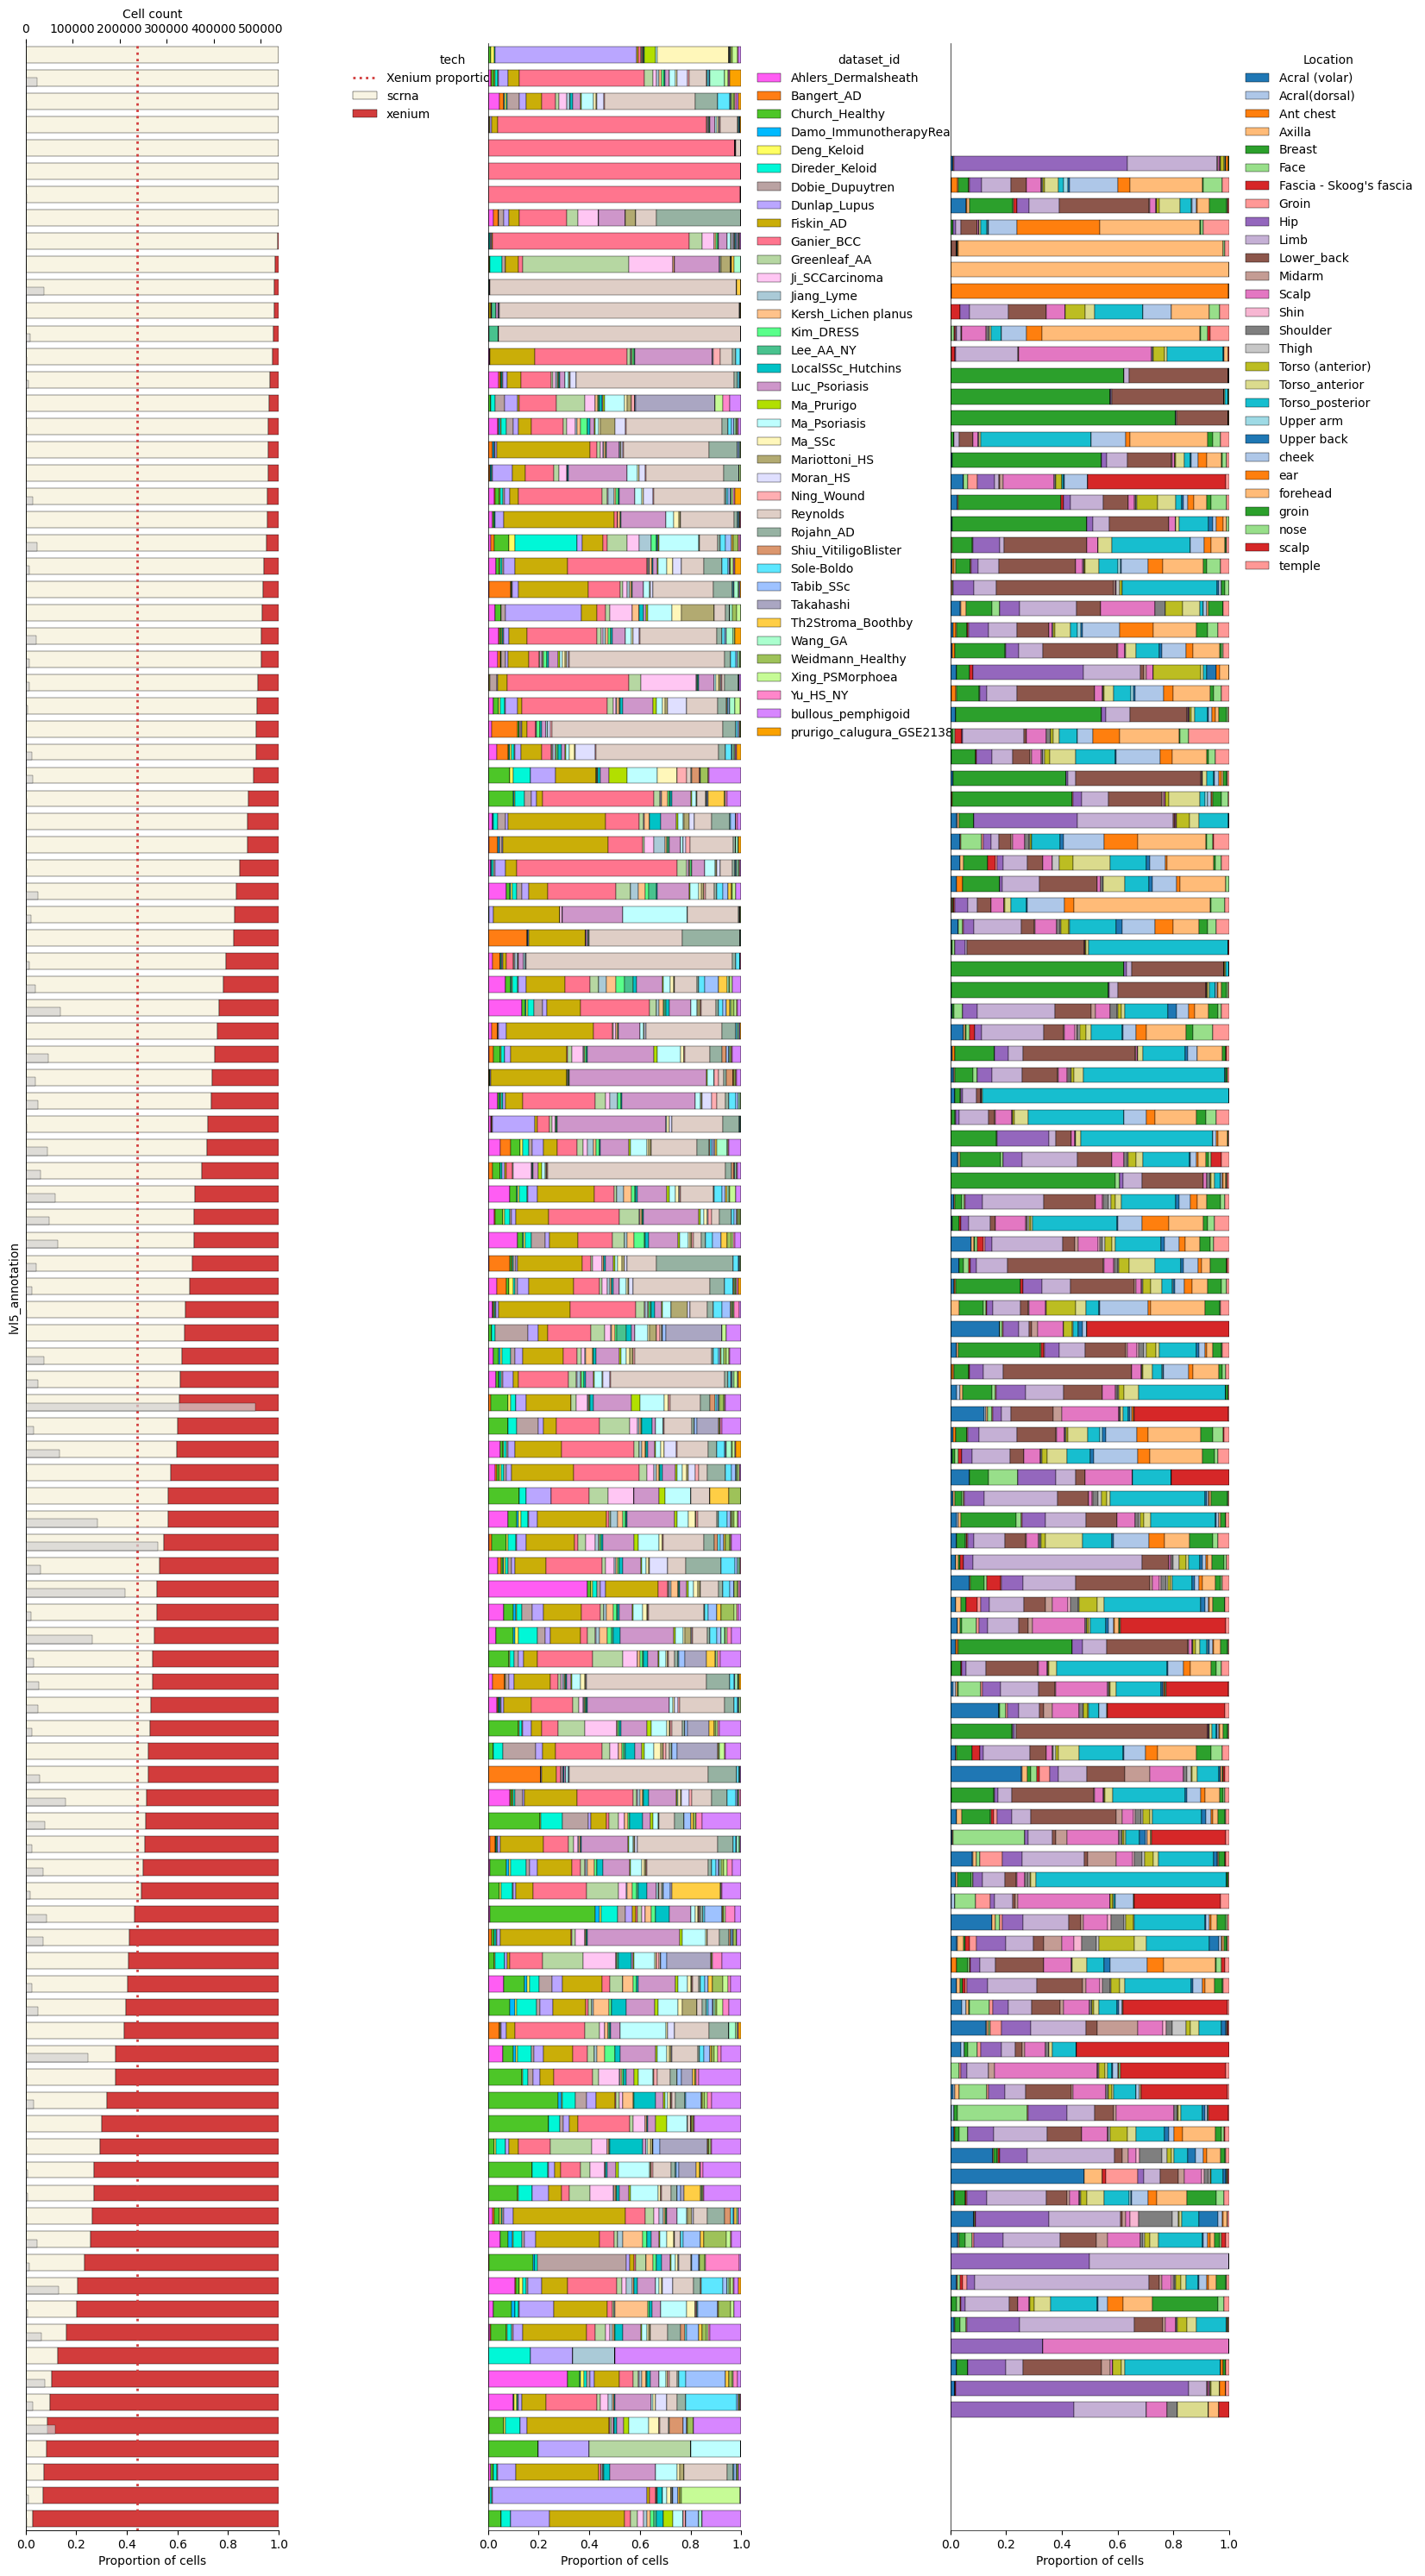

In [19]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import glasbey

# ----------------------------
# Inputs / derived quantities
# ----------------------------
counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
overall_props = adata.obs["tech"].value_counts(normalize=True)
xenium_frac = overall_props.get("xenium", 0.0)

# ----------------------------
# Dataset proportions for Glasbey plot
# ----------------------------
df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
y_order = props.index

dataset_props = (
    df_dset.groupby(["lvl5_annotation", "dataset_id"])
    .size()
    .unstack(fill_value=0)
)
dataset_props = (
    dataset_props.div(dataset_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

datasets = dataset_props.columns.tolist()
palette = glasbey.create_palette(
    palette_size=len(datasets),
    lightness_bounds=(60, 100),
    chroma_bounds=(0, 80)
)
dataset_colors = dict(zip(datasets, palette))

# ----------------------------
# Location proportions for third panel
# ----------------------------
df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

location_props = (
    df_loc.groupby(["lvl5_annotation", "Location"])
    .size()
    .unstack(fill_value=0)
)
location_props = (
    location_props.div(location_props.sum(axis=1), axis=0)
    .reindex(y_order)
    .fillna(0)
)
location_props = location_props.loc[location_props.sum(axis=1) > 0]

locations = location_props.columns
cmap = plt.get_cmap("tab20")
location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# ----------------------------
# Numeric y positions
# ----------------------------
y_pos = list(range(len(props)))

# ----------------------------
# Create combined figure: 1 row × 3 columns
# ----------------------------
fig = plt.figure(
    figsize=(18, max(4, 0.35 * len(props)))  # slightly wider for all legends
)

# Adjusted GridSpec: right plot slightly wider, more spacing
gs = GridSpec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.8)

# --- Left: stacked proportions + abundance bars ---
ax_left = fig.add_subplot(gs[0, 0])
ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# Stacked proportion bars
left_vals = [0.0] * len(props)
for tech in props.columns:
    ax_left.barh(
        y=y_pos,
        width=props[tech].values,
        left=left_vals,
        color=COLOR_DICT.get(tech, "grey"),
        edgecolor="black",
        linewidth=0.3,
        label=tech,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# Xenium reference
ax_left.axvline(
    xenium_frac,
    linestyle=":",
    linewidth=2,
    color=COLOR_DICT["xenium"],
    label="Xenium proportion (overall)"
)

ax_left.set_xlim(0, 1)
ax_left.set_xlabel("Proportion of cells")
ax_left.set_ylabel("lvl5_annotation")
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(props.index, fontsize=8)
ax_left.tick_params(axis="y", which="both", left=True, labelleft=True)

# Abundance bars: slightly shifted
ax_bar.barh(
    y=[y - 0.175 for y in y_pos],
    width=counts.values,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.7,
    height=0.35
)
ax_bar.set_xlim(0, counts.max() * 1.1)
ax_bar.set_xlabel("Cell count")
ax_bar.set_yticks([])

# --- Middle: dataset_id stacked proportions (Glasbey) ---
ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
left_vals = [0.0] * len(dataset_props)
for d in datasets:
    ax_middle.barh(
        y=y_pos,
        width=dataset_props[d].values,
        left=left_vals,
        color=dataset_colors[d],
        edgecolor="black",
        linewidth=0.3,
        label=d,
        height=0.7
    )
    left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

ax_middle.set_xlim(0, 1)
ax_middle.set_xlabel("Proportion of cells")
ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)

# --- Right: Location stacked proportions ---
# NOTE: Do NOT share y-axis with left; we want independent yticks
ax_right = fig.add_subplot(gs[0, 2])
left_vals = [0.0] * len(location_props)
for l in locations:
    ax_right.barh(
        y=y_pos,
        width=location_props[l].values,
        left=left_vals,
        color=location_colors[l],
        edgecolor="black",
        linewidth=0.3,
        label=l,
        height=0.7
    )
    left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

ax_right.set_xlim(0, 1)
ax_right.set_xlabel("Proportion of cells")

# Remove y-ticks and labels on right plot
ax_right.set_yticks([])
ax_right.set_yticklabels([])

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for a in (ax_left, ax_bar, ax_middle, ax_right):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.spines["left"].set_linewidth(0.5)
    a.spines["bottom"].set_linewidth(0.5)

ax_left.set_ylim(-0.5, len(props) - 0.5)

# Legends
ax_left.legend(
    title="tech",
    bbox_to_anchor=(1.25, 1),
    loc="upper left",
    frameon=False
)
ax_middle.legend(
    title="dataset_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
ax_right.legend(
    title="Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

plt.show()

In [20]:
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import pandas as pd
# import glasbey

# # ----------------------------
# # Inputs / derived quantities
# # ----------------------------
# counts = adata.obs["lvl5_annotation"].value_counts().reindex(props.index)
# overall_props = adata.obs["tech"].value_counts(normalize=True)
# xenium_frac = overall_props.get("xenium", 0.0)

# # ----------------------------
# # Dataset proportions for Glasbey plot
# # ----------------------------
# df_dset = adata_i.obs[["lvl5_annotation", "dataset_id"]].copy()
# y_order = props.index

# dataset_props = (
#     df_dset.groupby(["lvl5_annotation", "dataset_id"])
#     .size()
#     .unstack(fill_value=0)
# )
# dataset_props = (
#     dataset_props.div(dataset_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )
# dataset_props = dataset_props.loc[dataset_props.sum(axis=1) > 0]

# datasets = dataset_props.columns.tolist()
# palette = glasbey.create_palette(
#     palette_size=len(datasets),
#     lightness_bounds=(60, 100),
#     chroma_bounds=(0, 80)
# )
# dataset_colors = dict(zip(datasets, palette))

# # ----------------------------
# # Location proportions for third panel
# # ----------------------------
# df_loc = adata_ii.obs[["lvl5_annotation", "Location"]].copy()

# location_props = (
#     df_loc.groupby(["lvl5_annotation", "Location"])
#     .size()
#     .unstack(fill_value=0)
# )
# location_props = (
#     location_props.div(location_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )
# location_props = location_props.loc[location_props.sum(axis=1) > 0]

# locations = location_props.columns
# cmap = plt.get_cmap("tab20")
# location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# # ----------------------------
# # Numeric y positions
# # ----------------------------
# y_pos = list(range(len(props)))

# # ----------------------------
# # Create combined figure: 1 row × 3 columns
# # ----------------------------
# fig = plt.figure(
#     figsize=(18, max(4, 0.35 * len(props)))  # slightly wider for all legends
# )
# gs = GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.8)  # more space between middle and right

# # --- Left: stacked proportions + abundance bars ---
# ax_left = fig.add_subplot(gs[0, 0])
# ax_bar = ax_left.twiny()  # secondary x-axis for abundance

# # Stacked proportion bars
# left_vals = [0.0] * len(props)
# for tech in props.columns:
#     ax_left.barh(
#         y=y_pos,
#         width=props[tech].values,
#         left=left_vals,
#         color=COLOR_DICT.get(tech, "grey"),
#         edgecolor="black",
#         linewidth=0.3,
#         label=tech,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, props[tech].values)]

# # Xenium reference
# ax_left.axvline(
#     xenium_frac,
#     linestyle=":",
#     linewidth=2,
#     color=COLOR_DICT["xenium"],
#     label="Xenium proportion (overall)"
# )

# ax_left.set_xlim(0, 1)
# ax_left.set_xlabel("Proportion of cells")
# ax_left.set_ylabel("lvl5_annotation")
# ax_left.set_yticks(y_pos)
# ax_left.set_yticklabels(props.index)

# # Abundance bars: slightly shifted
# ax_bar.barh(
#     y=[y - 0.175 for y in y_pos],
#     width=counts.values,
#     color="lightgrey",
#     edgecolor="black",
#     linewidth=0.3,
#     alpha=0.7,
#     height=0.35
# )
# ax_bar.set_xlim(0, counts.max() * 1.1)
# ax_bar.set_xlabel("Cell count")
# ax_bar.set_yticks([])

# # --- Middle: dataset_id stacked proportions (Glasbey) ---
# ax_middle = fig.add_subplot(gs[0, 1], sharey=ax_left)
# left_vals = [0.0] * len(dataset_props)
# for d in datasets:
#     ax_middle.barh(
#         y=y_pos,
#         width=dataset_props[d].values,
#         left=left_vals,
#         color=dataset_colors[d],
#         edgecolor="black",
#         linewidth=0.3,
#         label=d,
#         height=0.7
#     )
#     left_vals = [l + v for l, v in zip(left_vals, dataset_props[d].values)]

# ax_middle.set_xlim(0, 1)
# ax_middle.set_xlabel("Proportion of cells")
# ax_middle.tick_params(axis="y", labelleft=False, labelsize=7)  # hide ylabels

# # --- Right: Location stacked proportions ---
# ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)
# left_vals = [0.0] * len(location_props)
# for l in locations:
#     ax_right.barh(
#         y=y_pos,
#         width=location_props[l].values,
#         left=left_vals,
#         color=location_colors[l],
#         edgecolor="black",
#         linewidth=0.3,
#         label=l,
#         height=0.7
#     )
#     left_vals = [lv + v for lv, v in zip(left_vals, location_props[l].values)]

# ax_right.set_xlim(0, 1)
# ax_right.set_xlabel("Proportion of cells")
# ax_right.tick_params(axis="y", labelleft=False, labelsize=7)  # hide ylabels here too

# # ----------------------------
# # Aesthetic cleanup
# # ----------------------------
# for a in (ax_left, ax_bar, ax_middle, ax_right):
#     a.spines["top"].set_visible(False)
#     a.spines["right"].set_visible(False)
#     a.spines["left"].set_linewidth(0.5)
#     a.spines["bottom"].set_linewidth(0.5)

# ax_left.set_ylim(-0.5, len(props) - 0.5)

# # Legends
# ax_left.legend(
#     title="tech",
#     bbox_to_anchor=(1.25, 1),
#     loc="upper left",
#     frameon=False
# )
# ax_middle.legend(
#     title="dataset_id",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )
# ax_right.legend(
#     title="Location",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

In [21]:
# # Subset
# df = adata_i.obs[["lvl5_annotation", "Location"]].copy()

# # Fixed y-axis order
# y_order = props.index

# # ----------------------------
# # Compute proportions per lvl5_annotation
# # ----------------------------
# location_props = (
#     df.groupby(["lvl5_annotation", "Location"])
#       .size()
#       .unstack(fill_value=0)
# )

# # Normalize within each lvl5_annotation
# location_props = (
#     location_props
#     .div(location_props.sum(axis=1), axis=0)
#     .reindex(y_order)
#     .fillna(0)
# )

# # ----------------------------
# # Filter out empty populations
# # ----------------------------
# location_props = location_props.loc[location_props.sum(axis=1) > 0]

# # ----------------------------
# # Color map for locations
# # ----------------------------
# locations = location_props.columns
# cmap = plt.get_cmap("tab20")
# location_colors = {l: cmap(i % cmap.N) for i, l in enumerate(locations)}

# # ----------------------------
# # Plot
# # ----------------------------
# fig, ax = plt.subplots(
#     figsize=(8, max(4, 0.35 * len(location_props)))
# )

# left = pd.Series(0.0, index=location_props.index)

# for l in locations:
#     ax.barh(
#         location_props.index,
#         location_props[l],
#         left=left,
#         color=location_colors[l],
#         edgecolor="black",
#         linewidth=0.3,
#         label=l
#     )
#     left += location_props[l]

# # ----------------------------
# # Aesthetics
# # ----------------------------
# ax.set_xlim(0, 1)
# ax.set_xlabel("Proportion of cells")
# ax.set_ylabel("lvl5_annotation")
# ax.set_ylim(-0.5, len(location_props) - 0.5)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_linewidth(0.5)
# ax.spines["bottom"].set_linewidth(0.5)

# ax.legend(
#     title="Location",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# plt.tight_layout()
# plt.show()

In [22]:
adata_xenium=adata[adata.obs["tech"]=="xenium"].copy()


In [23]:
sc.pp.calculate_qc_metrics(adata_xenium, percent_top=(10, 20, 50, 150), inplace=True)


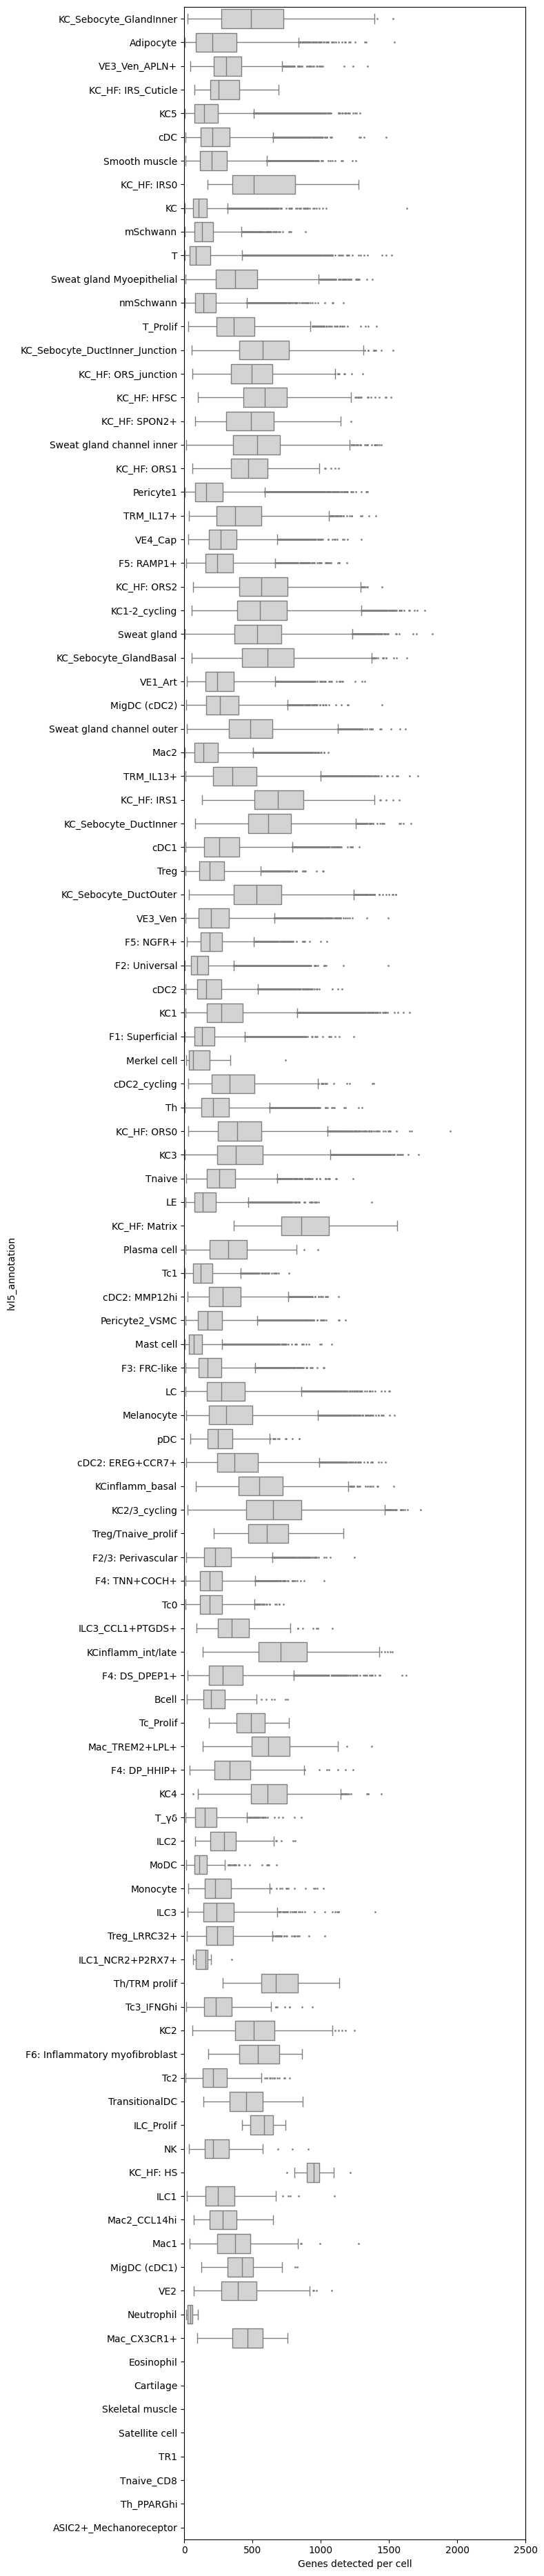

In [24]:
# --------------------------------
# Reuse ordering from xenium plot
# --------------------------------
order = props.index.tolist()   # DO NOT recompute

# --------------------------------
# Prepare data
# --------------------------------
df = adata_xenium.obs[["lvl5_annotation", "n_genes_by_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["n_genes_by_counts"] = pd.to_numeric(
    df["n_genes_by_counts"], errors="coerce"
)
df = df.dropna(subset=["n_genes_by_counts"])

# Keep only categories in the desired order
df = df[df["lvl5_annotation"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="n_genes_by_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Genes detected per cell")
ax.set_ylabel("lvl5_annotation")
ax.set_xlim(0, 2500)

plt.tight_layout()
plt.show()

In [25]:
adata.obs.tech.value_counts()

tech
scrna     1730938
xenium    1369152
Name: count, dtype: int64

In [26]:
# adata_i.obs["dataset_id"].value_counts()

In [27]:
# y_order

In [28]:
import scanpy as sc

# Compute QC if not already done — adds n_genes_by_counts and total_counts to .obs
sc.pp.calculate_qc_metrics(adata_xenium, inplace=True, log1p=False, percent_top=None)

genes = adata_xenium.obs["n_genes_by_counts"]
counts = adata_xenium.obs["total_counts"]

print(f"Genes per cell:       {genes.mean():.1f} ± {genes.std():.1f}")
print(f"Transcripts per cell: {counts.mean():.1f} ± {counts.std():.1f}")

Genes per cell:       287.3 ± 229.0
Transcripts per cell: 429.3 ± 458.2


In [29]:
s

NameError: name 's' is not defined

In [ ]:
adata_xenium.obs.sample_id.value_counts()

In [ ]:

# --------------------------------
# Prepare data
# --------------------------------
df = adata_xenium.obs[["sample_id", "n_genes_by_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["n_genes_by_counts"] = pd.to_numeric(
    df["n_genes_by_counts"], errors="coerce"
)
df = df.dropna(subset=["n_genes_by_counts"])

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="n_genes_by_counts",
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Genes detected per cell")
ax.set_ylabel("sample_id")
ax.set_xlim(0, 2000)

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------
# Prepare data
# --------------------------------
df = adata_xenium.obs[["sample_id", "total_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the desired order
#df = df[df["sample_id"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="total_counts",
    #order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("sample_id")

ax.set_xlim(0, 3000)


plt.tight_layout()
plt.show()

In [ ]:
# # --------------------------------
# # Plot horizontal boxplots
# # --------------------------------
# fig, ax = plt.subplots(
#     figsize=(8, max(4, 0.35 * len(order)))
# )

# sns.boxplot(
#     data=df,
#     y="lvl5_annotation",
#     x="total_counts",
#     order=order,          # ← now sorted by mean
#     orient="h",
#     ax=ax,
#     color="lightgrey",
#     fliersize=1,
#     linewidth=1,
# )

# ax.set_xlabel("Total counts per cell")
# ax.set_ylabel("lvl5_annotation")
# ax.set_xlim(0, 5000)

# plt.tight_layout()
# plt.show()

In [ ]:
# ----------------------------
# Reuse the SAME order as before
# ----------------------------
order = props.index.tolist()   # from the previous xenium-sorted plot

# ----------------------------
# Build plotting DataFrame
# ----------------------------
df = adata_xenium.obs[["lvl5_annotation", "total_counts"]].copy()

# Force numeric (Scanpy loves categories…)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the order
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot horizontal boxplots
# ----------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")

plt.tight_layout()
plt.show()



# Skin panel only

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

PATH = '/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_TUTORIAL_XENIUMskinpanel_HVGNUMBER259__MAXEPOCHS20__BATCHKEYsample_id/adata_TUTORIAL_XENIUMskinpanel+HVGNUMBER259__MAXEPOCHS20__BATCHKEYsample_id.h5ad'
adata_skinpanel=sc.read_h5ad(PATH)
adata_skinpanel=adata_skinpanel[adata_skinpanel.obs["Mapping_status"]!="SpatialSkinAtlas"].copy()


In [ ]:
# --------------------------------
# Prepare data
# --------------------------------
df = adata_skinpanel.obs[["sample_id", "total_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the desired order
#df = df[df["sample_id"].isin(order)]

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(5, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="total_counts",
    #order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("sample_id")

ax.set_xlim(0, 2500)


plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------
# Prepare data
# --------------------------------
df = adata_skinpanel.obs[["sample_id", "n_genes_by_counts"]].copy()

# Force numeric (Scanpy categories are a menace)
df["n_genes_by_counts"] = pd.to_numeric(
    df["n_genes_by_counts"], errors="coerce"
)
df = df.dropna(subset=["n_genes_by_counts"])

# --------------------------------
# Plot horizontal boxplots
# --------------------------------
fig, ax = plt.subplots(
    figsize=(5, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="sample_id",
    x="n_genes_by_counts",
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# --------------------------------
# Labels / aesthetics
# --------------------------------
ax.set_xlabel("Genes detected per cell")
ax.set_ylabel("sample_id")
ax.set_xlim(0, 2500)

plt.tight_layout()
plt.show()

In [ ]:
adata_skinpanel.obs["lvl5_annotation"]=adata_skinpanel.obs["scanvi_predictions"]
# ----------------------------
# Reuse the SAME order as before
# ----------------------------
order = props.index.tolist()   # from the previous xenium-sorted plot

# ----------------------------
# Build plotting DataFrame
# ----------------------------
df = adata_skinpanel.obs[["lvl5_annotation", "total_counts"]].copy()

# Force numeric (Scanpy loves categories…)
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only categories in the order
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot horizontal boxplots
# ----------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")

plt.tight_layout()
plt.show()

In [ ]:
adata_skinpanel.obs["lvl5_annotation"] = adata_skinpanel.obs["scanvi_predictions"]

# ----------------------------
# Reuse the SAME order as before
# ----------------------------
order = props.index.tolist()   # from the previous xenium-sorted plot

# ----------------------------
# Build plotting DataFrame
# ----------------------------
df = adata_skinpanel.obs[["lvl5_annotation", "n_genes_by_counts"]].copy()

# Force numeric (Scanpy loves categories…)
df["n_genes_by_counts"] = pd.to_numeric(
    df["n_genes_by_counts"], errors="coerce"
)
df = df.dropna(subset=["n_genes_by_counts"])

# Keep only categories in the order
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot horizontal boxplots
# ----------------------------
fig, ax = plt.subplots(
    figsize=(8, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="n_genes_by_counts",
    order=order,
    orient="h",
    ax=ax,
    color="lightgrey",
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Genes detected per cell")
ax.set_ylabel("lvl5_annotation")

plt.tight_layout()
plt.show()

# FFPE panel

In [ ]:
# ----------------------------
# Reuse ordering
# ----------------------------
order = props.index.tolist()

# ----------------------------
# Xenium
# ----------------------------
df_xen = adata_xenium.obs[["lvl5_annotation", "total_counts"]].copy()
df_xen["dataset"] = "Xenium"

# ----------------------------
# Skin panel
# ----------------------------
adata_skinpanel.obs["lvl5_annotation"] = adata_skinpanel.obs["scanvi_predictions"]

df_skin = adata_skinpanel.obs[["lvl5_annotation", "total_counts"]].copy()
df_skin["dataset"] = "Skin panel"

# ----------------------------
# Combine
# ----------------------------
df = pd.concat([df_xen, df_skin], axis=0)

# Force numeric
df["total_counts"] = pd.to_numeric(df["total_counts"], errors="coerce")
df = df.dropna(subset=["total_counts"])

# Keep only ordered categories
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(
    figsize=(9, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="total_counts",
    hue="dataset",
    order=order,
    orient="h",
    dodge=True,
    ax=ax,
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Total counts per cell")
ax.set_ylabel("lvl5_annotation")

ax.legend(
    title="Dataset",
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------
# Reuse ordering
# ----------------------------
order = props.index.tolist()

# ----------------------------
# Xenium
# ----------------------------
df_xen = adata_xenium.obs[["lvl5_annotation", "n_genes_by_counts"]].copy()
df_xen["dataset"] = "Xenium"

# ----------------------------
# Skin panel
# ----------------------------
adata_skinpanel.obs["lvl5_annotation"] = adata_skinpanel.obs["scanvi_predictions"]

df_skin = adata_skinpanel.obs[["lvl5_annotation", "n_genes_by_counts"]].copy()
df_skin["dataset"] = "Skin panel"

# ----------------------------
# Combine
# ----------------------------
df = pd.concat([df_xen, df_skin], axis=0)

# Force numeric (because pandas is fragile)
df["n_genes_by_counts"] = pd.to_numeric(
    df["n_genes_by_counts"], errors="coerce"
)
df = df.dropna(subset=["n_genes_by_counts"])

# Keep only ordered categories
df = df[df["lvl5_annotation"].isin(order)]

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(
    figsize=(9, max(4, 0.35 * len(order)))
)

sns.boxplot(
    data=df,
    y="lvl5_annotation",
    x="n_genes_by_counts",
    hue="dataset",
    order=order,
    orient="h",
    dodge=True,
    ax=ax,
    fliersize=1,
    linewidth=1,
)

# ----------------------------
# Aesthetics
# ----------------------------
ax.set_xlabel("Number of genes detected per cell")
ax.set_ylabel("lvl5_annotation")

ax.legend(
    title="Dataset",
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
adata_i.obs.tech.value_counts()

In [ ]:
import pandas as pd

df = adata_xenium.obs

per_sample = (
    df.groupby("sample_id")[[
        "control_probe_counts",
        "control_codeword_counts",
        "total_counts"
    ]]
    .sum()
)

per_sample["cprobes_pct"] = (
    per_sample["control_probe_counts"]
    / per_sample["total_counts"]
    * 100
)

per_sample["cwords_pct"] = (
    per_sample["control_codeword_counts"]
    / per_sample["total_counts"]
    * 100
)

print(per_sample[["cprobes_pct", "cwords_pct"]])



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 4))

per_sample[["cprobes_pct", "cwords_pct"]].plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Percentage of total counts")
ax.set_xlabel("Sample ID")
ax.set_title("Negative control signal per sample")
ax.legend(["Negative DNA probes", "Negative decoding"])
ax.set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = adata_skinpanel.obs

per_sample = (
    df.groupby("sample_id")[[
        "control_probe_counts",
        "control_codeword_counts",
        "total_counts"
    ]]
    .sum()
)

per_sample["cprobes_pct"] = (
    per_sample["control_probe_counts"]
    / per_sample["total_counts"]
    * 100
)

per_sample["cwords_pct"] = (
    per_sample["control_codeword_counts"]
    / per_sample["total_counts"]
    * 100
)

print(per_sample[["cprobes_pct", "cwords_pct"]])



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 4))

per_sample[["cprobes_pct", "cwords_pct"]].plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Percentage of total counts")
ax.set_xlabel("Sample ID")
ax.set_title("Negative control signal per sample")
ax.legend(["Negative DNA probes", "Negative decoding"])
ax.set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Compute per-sample percentages
# -----------------------------
def compute_control_percentages(adata, label):
    df = adata.obs

    per_sample = (
        df.groupby("sample_id")[[
            "control_probe_counts",
            "control_codeword_counts",
            "total_counts"
        ]]
        .sum()
    )

    per_sample["cprobes_pct"] = (
        per_sample["control_probe_counts"]
        / per_sample["total_counts"]
        * 100
    )

    per_sample["cwords_pct"] = (
        per_sample["control_codeword_counts"]
        / per_sample["total_counts"]
        * 100
    )

    per_sample = per_sample.reset_index()
    per_sample["dataset"] = label

    return per_sample


# -----------------------------
# Compute for both datasets
# -----------------------------
df_main = compute_control_percentages(adata, "main")
df_skin = compute_control_percentages(adata_skinpanel, "skinpanel")

df_all = pd.concat([df_main, df_skin], ignore_index=True)


# -----------------------------
# Plot (single figure)
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 4))

for dataset, d in df_all.groupby("dataset"):
    ax.scatter(
        d["sample_id"],
        d["cprobes_pct"],
        marker="o",
        label=f"probes ({dataset})"
    )
    ax.scatter(
        d["sample_id"],
        d["cwords_pct"],
        marker="x",
        label=f"codewords ({dataset})"
    )

ax.set_xlabel("Sample ID")
ax.set_ylabel("Percentage of total counts")
ax.set_title("Negative control signal per sample")

ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()